In [80]:
# Importing necessary packages

import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import scipy.stats as stats
from scipy.stats import shapiro


from sklearn.preprocessing import  LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
#from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_squared_error

Importing Data

In [3]:
data = pd.read_csv(r"C:\Users\hp\Desktop\Categorized Folders\unt\Emperiical Analysis\Project\Airbnb_Data.csv")

In [81]:
data

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74106,14549287,4.605170,Apartment,Private room,{},1,1.0,Real Bed,flexible,False,...,40.709025,-73.939405,one room bushwick,Williamsburg,0,NaN,https://a0.muscache.com/im/pictures/55162426/6...,11206.0,1.0,1.0
74107,13281809,5.043425,Apartment,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,2.0,Real Bed,moderate,True,...,33.871549,-118.396053,Spacious Hermosa 2 BR on PCH,Hermosa Beach,16,93.0,https://a0.muscache.com/im/pictures/2b86560b-a...,90254,2.0,4.0
74108,18688039,5.220356,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",5,1.0,Real Bed,moderate,True,...,40.706749,-73.942377,Modern 2 Bedroom Apartment in Williamsburg,Williamsburg,43,94.0,https://a0.muscache.com/im/pictures/7fbe448c-5...,11206.0,2.0,2.0
74109,17045948,5.273000,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",2,1.0,Real Bed,strict,True,...,40.738535,-74.000157,Designer's Apartment in HEART of NYC,West Village,0,NaN,https://a0.muscache.com/im/pictures/b3971b63-0...,10011,0.0,2.0


In [5]:
data.shape

(74111, 29)

In [6]:
data.columns

Index(['id', 'log_price', 'property_type', 'room_type', 'amenities',
       'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy',
       'cleaning_fee', 'city', 'description', 'first_review',
       'host_has_profile_pic', 'host_identity_verified', 'host_response_rate',
       'host_since', 'instant_bookable', 'last_review', 'latitude',
       'longitude', 'name', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'thumbnail_url', 'zipcode', 'bedrooms', 'beds'],
      dtype='object')

In [7]:
data.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [8]:
data.describe()

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,7.411100e+04,74111.000000,74111.000000,73911.000000,74111.000000,74111.000000,74111.000000,57389.000000,74020.000000,73980.000000
mean,1.126662e+07,4.782069,3.155146,1.235263,38.445958,-92.397525,20.900568,94.067365,1.265793,1.710868
std,6.081735e+06,0.717394,2.153589,0.582044,3.080167,21.705322,37.828641,7.836556,0.852143,1.254142
min,3.440000e+02,0.000000,1.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000
25%,6.261964e+06,4.317488,2.000000,1.000000,34.127908,-118.342374,1.000000,92.000000,1.000000,1.000000
50%,1.225415e+07,4.709530,2.000000,1.000000,40.662138,-76.996965,6.000000,96.000000,1.000000,1.000000
75%,1.640226e+07,5.220356,4.000000,1.000000,40.746096,-73.954660,23.000000,100.000000,1.000000,2.000000
max,2.123090e+07,7.600402,16.000000,8.000000,42.390437,-70.985047,605.000000,100.000000,10.000000,18.000000


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73923 non-null

In [10]:
data.dtypes

id                          int64
log_price                 float64
property_type              object
room_type                  object
amenities                  object
accommodates                int64
bathrooms                 float64
bed_type                   object
cancellation_policy        object
cleaning_fee                 bool
city                       object
description                object
first_review               object
host_has_profile_pic       object
host_identity_verified     object
host_response_rate         object
host_since                 object
instant_bookable           object
last_review                object
latitude                  float64
longitude                 float64
name                       object
neighbourhood              object
number_of_reviews           int64
review_scores_rating      float64
thumbnail_url              object
zipcode                    object
bedrooms                  float64
beds                      float64
dtype: object

In [11]:
data.isnull().sum()

id                            0
log_price                     0
property_type                 0
room_type                     0
amenities                     0
accommodates                  0
bathrooms                   200
bed_type                      0
cancellation_policy           0
cleaning_fee                  0
city                          0
description                   0
first_review              15864
host_has_profile_pic        188
host_identity_verified      188
host_response_rate        18299
host_since                  188
instant_bookable              0
last_review               15827
latitude                      0
longitude                     0
name                          0
neighbourhood              6872
number_of_reviews             0
review_scores_rating      16722
thumbnail_url              8216
zipcode                     966
bedrooms                     91
beds                        131
dtype: int64

In [12]:
data['zipcode'].value_counts()

zipcode
11211.0    1368
90291      1274
11221      1188
94110       988
90046       967
           ... 
10019.0       1
92397         1
60805         1
10007.0       1
10012.0       1
Name: count, Length: 769, dtype: int64

Handling Data

In [13]:
# We will first compare zipcodes to make sure values are unique

data['zipcode'].unique

<bound method Series.unique of 0          11201
1          10019
2          10027
3        94117.0
4          20009
          ...   
74106    11206.0
74107      90254
74108    11206.0
74109      10011
74110      90802
Name: zipcode, Length: 74111, dtype: object>

In [14]:
data['review_scores_rating'].median()

np.float64(96.0)

In [15]:
# We will select a few columns and compare its value counts

select_cols = ["property_type", "room_type","accommodates","bathrooms","bed_type", "cancellation_policy", "cleaning_fee",
       "city","instant_bookable", "beds", "bedrooms", "neighbourhood","zipcode","name","host_since", "latitude", "longitude"]


for cols in select_cols:
    print(data[cols].value_counts(), "\n")
    print("------------------------------------------------------------------")

property_type
Apartment             49003
House                 16511
Condominium            2658
Townhouse              1692
Loft                   1244
Other                   607
Guesthouse              498
Bed & Breakfast         462
Bungalow                366
Villa                   179
Dorm                    142
Guest suite             123
Camper/RV                94
Timeshare                77
Cabin                    72
In-law                   71
Hostel                   70
Boutique hotel           69
Boat                     65
Serviced apartment       21
Tent                     18
Castle                   13
Vacation home            11
Yurt                      9
Hut                       8
Treehouse                 7
Chalet                    6
Earth House               4
Tipi                      3
Cave                      2
Train                     2
Casa particular           1
Parking Space             1
Lighthouse                1
Island                    1
Name: 

Columns to drop

- first review
- last review
- cancellation_policy
- description
- host_has_profile_pic
- host_identity_verified
- name
- thumbnail_url


In [16]:
columns_to_drop = ['id',
    'first_review',
    'last_review',
    'cancellation_policy',
    'description',
    'host_has_profile_pic',
    'host_identity_verified',
    'name',
    'thumbnail_url',
    'host_response_rate',
    'host_since'
]

data_17_cols = data.drop(columns=columns_to_drop, errors='ignore')

In [17]:
data_17_cols.columns

Index(['log_price', 'property_type', 'room_type', 'amenities', 'accommodates',
       'bathrooms', 'bed_type', 'cleaning_fee', 'city', 'instant_bookable',
       'latitude', 'longitude', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'zipcode', 'bedrooms', 'beds'],
      dtype='object')

In [18]:
data_17_cols

,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cleaning_fee,city,instant_bookable,latitude,longitude,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,True,NYC,f,40.696524,-73.991617,Brooklyn Heights,2,100.0,11201,1.0,1.0
1,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,True,NYC,t,40.766115,-73.989040,Hell's Kitchen,6,93.0,10019,3.0,3.0
2,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,True,NYC,t,40.808110,-73.943756,Harlem,10,92.0,10027,1.0,3.0
3,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,True,SF,f,37.772004,-122.431619,Lower Haight,0,NaN,94117.0,2.0,2.0
4,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,True,DC,t,38.925627,-77.034596,Columbia Heights,4,40.0,20009,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74106,4.605170,Apartment,Private room,{},1,1.0,Real Bed,False,NYC,f,40.709025,-73.939405,Williamsburg,0,NaN,11206.0,1.0,1.0
74107,5.043425,Apartment,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,2.0,Real Bed,True,LA,f,33.871549,-118.396053,Hermosa Beach,16,93.0,90254,2.0,4.0
74108,5.220356,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",5,1.0,Real Bed,True,NYC,t,40.706749,-73.942377,Williamsburg,43,94.0,11206.0,2.0,2.0
74109,5.273000,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",2,1.0,Real Bed,True,NYC,t,40.738535,-74.000157,West Village,0,NaN,10011,0.0,2.0


In [19]:
amenities_count = []
for i in data_17_cols["amenities"]:
    amenities_count.append(len(i))
    
data_17_cols["amenities"] = amenities_count

In [20]:
data_17_cols['cleaning_fee'] = data_17_cols['cleaning_fee'].map({True: 1, False: 0})
data_17_cols['instant_bookable'] = data_17_cols['instant_bookable'].map({'t': 1, 'f': 0})


In [21]:
data_17_cols

,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cleaning_fee,city,instant_bookable,latitude,longitude,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5.010635,Apartment,Entire home/apt,152,3,1.0,Real Bed,1,NYC,0,40.696524,-73.991617,Brooklyn Heights,2,100.0,11201,1.0,1.0
1,5.129899,Apartment,Entire home/apt,218,7,1.0,Real Bed,1,NYC,1,40.766115,-73.989040,Hell's Kitchen,6,93.0,10019,3.0,3.0
2,4.976734,Apartment,Entire home/apt,311,5,1.0,Real Bed,1,NYC,1,40.808110,-73.943756,Harlem,10,92.0,10027,1.0,3.0
3,6.620073,House,Entire home/apt,210,4,1.0,Real Bed,1,SF,0,37.772004,-122.431619,Lower Haight,0,NaN,94117.0,2.0,2.0
4,4.744932,Apartment,Entire home/apt,174,2,1.0,Real Bed,1,DC,1,38.925627,-77.034596,Columbia Heights,4,40.0,20009,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74106,4.605170,Apartment,Private room,2,1,1.0,Real Bed,0,NYC,0,40.709025,-73.939405,Williamsburg,0,NaN,11206.0,1.0,1.0
74107,5.043425,Apartment,Entire home/apt,224,4,2.0,Real Bed,1,LA,0,33.871549,-118.396053,Hermosa Beach,16,93.0,90254,2.0,4.0
74108,5.220356,Apartment,Entire home/apt,402,5,1.0,Real Bed,1,NYC,1,40.706749,-73.942377,Williamsburg,43,94.0,11206.0,2.0,2.0
74109,5.273000,Apartment,Entire home/apt,189,2,1.0,Real Bed,1,NYC,1,40.738535,-74.000157,West Village,0,NaN,10011,0.0,2.0


In [22]:
data_17_cols.isnull().sum()

log_price                   0
property_type               0
room_type                   0
amenities                   0
accommodates                0
bathrooms                 200
bed_type                    0
cleaning_fee                0
city                        0
instant_bookable            0
latitude                    0
longitude                   0
neighbourhood            6872
number_of_reviews           0
review_scores_rating    16722
zipcode                   966
bedrooms                   91
beds                      131
dtype: int64

Filling neighbourhood by using city, longitude and latitude with nearest neighbour imputation

In [23]:
from sklearn.neighbors import BallTree

# Function to fill missing neighbourhoods per city
def fill_neighbourhood(city_group):
    known = city_group[city_group['neighbourhood'].notnull()]
    missing = city_group[city_group['neighbourhood'].isnull()]
    
    if missing.empty:
        return city_group

    # BallTree with known coordinates
    tree = BallTree(np.radians(known[['latitude', 'longitude']]), metric='haversine')

    # Query closest neighbourhood
    dist, idx = tree.query(np.radians(missing[['latitude', 'longitude']]), k=1)

    # Fill missing values
    missing_indices = missing.index
    city_group.loc[missing_indices, 'neighbourhood'] = known.iloc[idx.flatten()]['neighbourhood'].values
    
    return city_group

# Apply per city directly to your dataframe
data_17_filled = data_17_cols.groupby('city').apply(fill_neighbourhood).reset_index(drop=True)


In [24]:
# Function to fill missing zipcodes per city
def fill_zipcode(city_group):
    known = city_group[city_group['zipcode'].notnull()]
    missing = city_group[city_group['zipcode'].isnull()]
    
    if missing.empty or known.empty:
        return city_group

    # Build BallTree with known coordinates
    tree = BallTree(np.radians(known[['latitude', 'longitude']]), metric='haversine')

    # Query closest known zipcode
    dist, idx = tree.query(np.radians(missing[['latitude', 'longitude']]), k=1)

    # Fill missing zipcodes
    missing_indices = missing.index
    city_group.loc[missing_indices, 'zipcode'] = known.iloc[idx.flatten()]['zipcode'].values
    
    return city_group

# Apply per city directly to your dataframe
data_17_filled = data_17_filled.groupby('city').apply(fill_zipcode).reset_index(drop=True)


In [25]:
data_17_filled.isnull().sum()

log_price                   0
property_type               0
room_type                   0
amenities                   0
accommodates                0
bathrooms                 200
bed_type                    0
cleaning_fee                0
city                        0
instant_bookable            0
latitude                    0
longitude                   0
neighbourhood               0
number_of_reviews           0
review_scores_rating    16722
zipcode                     0
bedrooms                   91
beds                      131
dtype: int64

In [26]:
data_17_filled["bathrooms"] = data_17_filled['bathrooms'].fillna(round(data_17_filled["bathrooms"].median()))
data_17_filled["review_scores_rating"] = data_17_filled["review_scores_rating"].fillna(0)
data_17_filled["bedrooms"] = data_17_filled['bedrooms'].fillna((data_17_filled["bathrooms"].median()))
data_17_filled["beds"] = data_17_filled["beds"].fillna((data_17_filled["bathrooms"].median()))

In [27]:
data_17_filled.isnull().sum()

log_price               0
property_type           0
room_type               0
amenities               0
accommodates            0
bathrooms               0
bed_type                0
cleaning_fee            0
city                    0
instant_bookable        0
latitude                0
longitude               0
neighbourhood           0
number_of_reviews       0
review_scores_rating    0
zipcode                 0
bedrooms                0
beds                    0
dtype: int64

# EDA

## Univariate

### Numerical

In [28]:
def histogram_boxplot(feature, figsize=(15,10), bins=None):
    """
    Combined boxplot and histogram with mean and median lines.

    Parameters:
    - feature: 1D array or Pandas Series
    - figsize: Tuple for figure size
    - bins: Number of histogram bins (optional)
    """
    fig, (ax_box, ax_hist) = plt.subplots(
        nrows=2,
        sharex=False,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize
    )

    # Boxplot with mean indicator
    sns.boxplot(x=feature, ax=ax_box, showmeans=True, color='violet')
    ax_box.set(xlabel='')

    # Histogram (handle bins parameter properly)
    hist_kwargs = dict(kde=True, ax=ax_hist, color='skyblue')
    if bins is not None:
        hist_kwargs['bins'] = bins

    sns.histplot(feature, **hist_kwargs)

    # Mean and median lines
    mean_value = np.mean(feature)
    median_value = np.median(feature)
    ax_hist.axvline(mean_value, color='green', linestyle='--', label=f'Mean: {mean_value:.2f}')
    ax_hist.axvline(median_value, color='black', linestyle='-', label=f'Median: {median_value:.2f}')

    ax_hist.legend()
    plt.show()


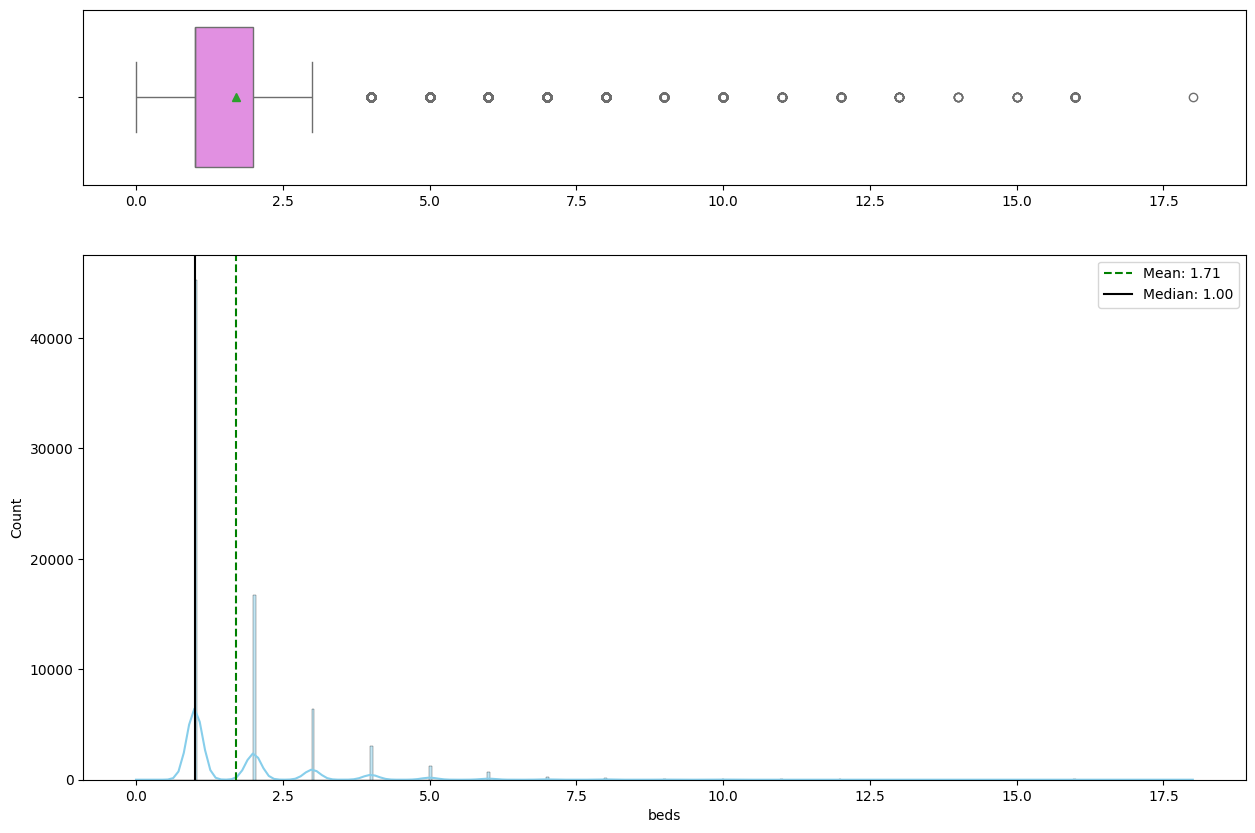

In [29]:
histogram_boxplot(data_17_filled['beds'])

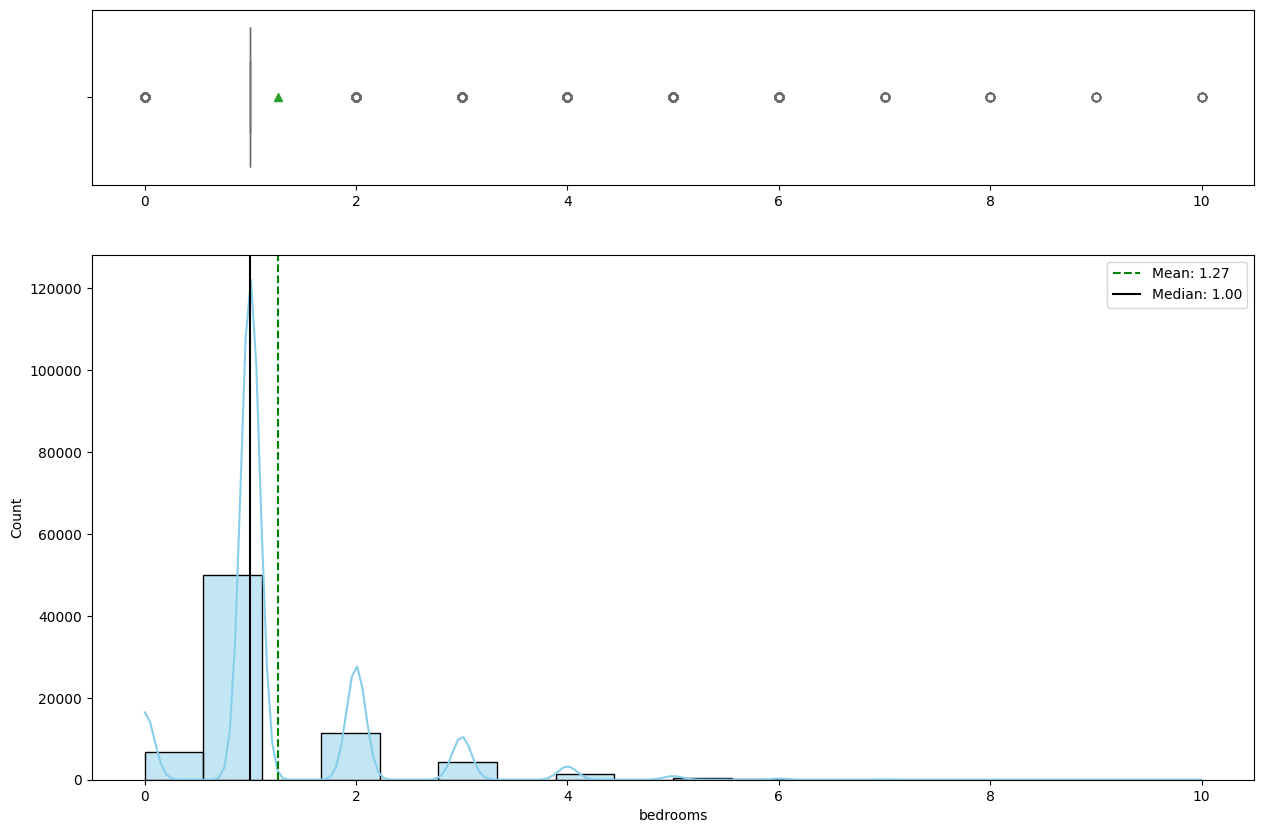

In [30]:
histogram_boxplot(data_17_filled['bedrooms'])

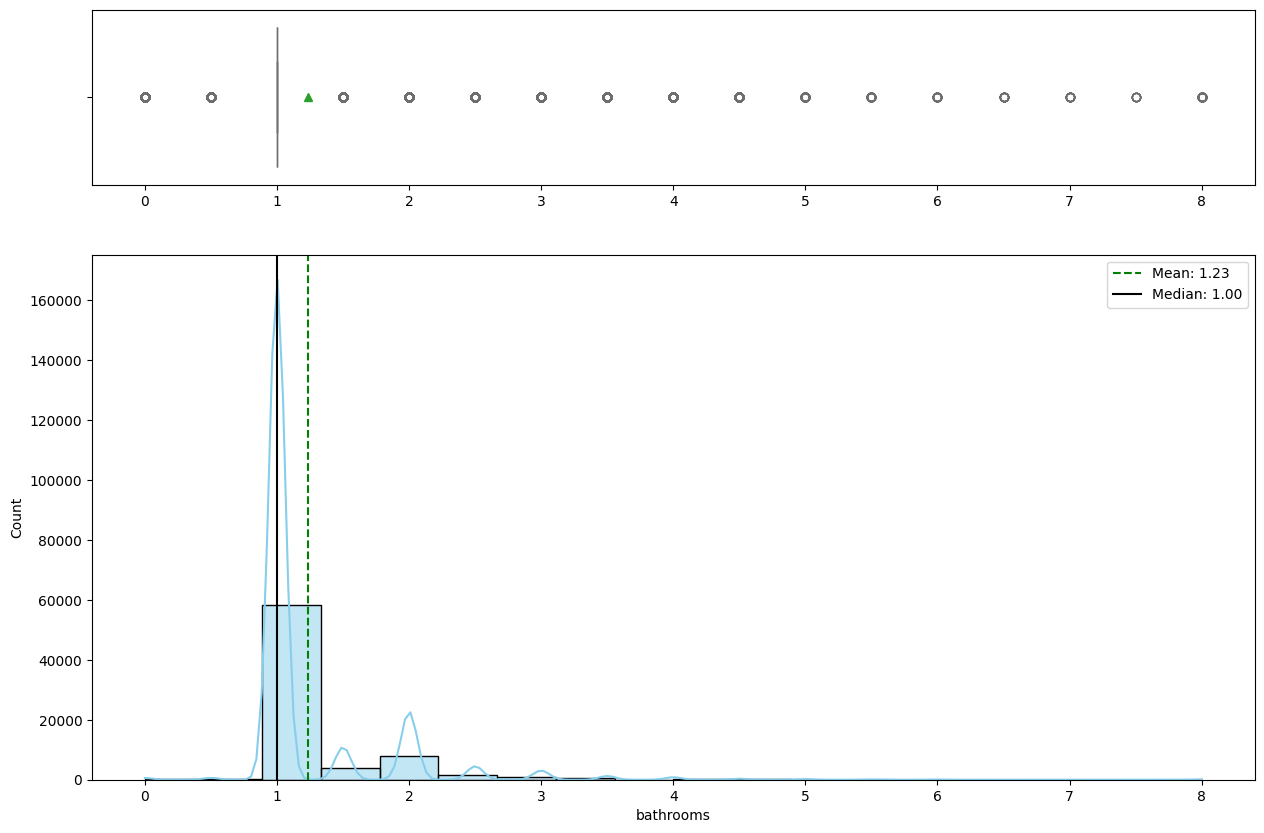

In [31]:
histogram_boxplot(data_17_filled['bathrooms'])

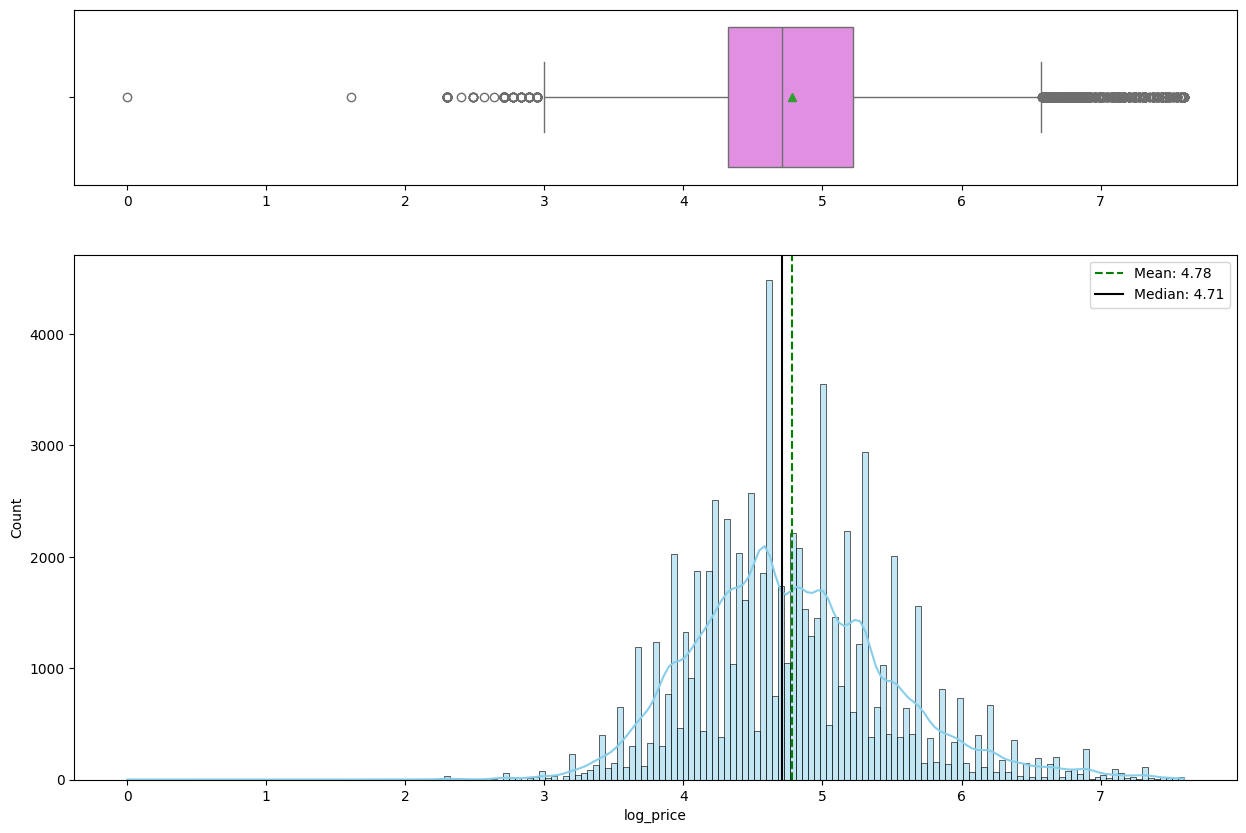

In [32]:
histogram_boxplot(data_17_filled['log_price'])

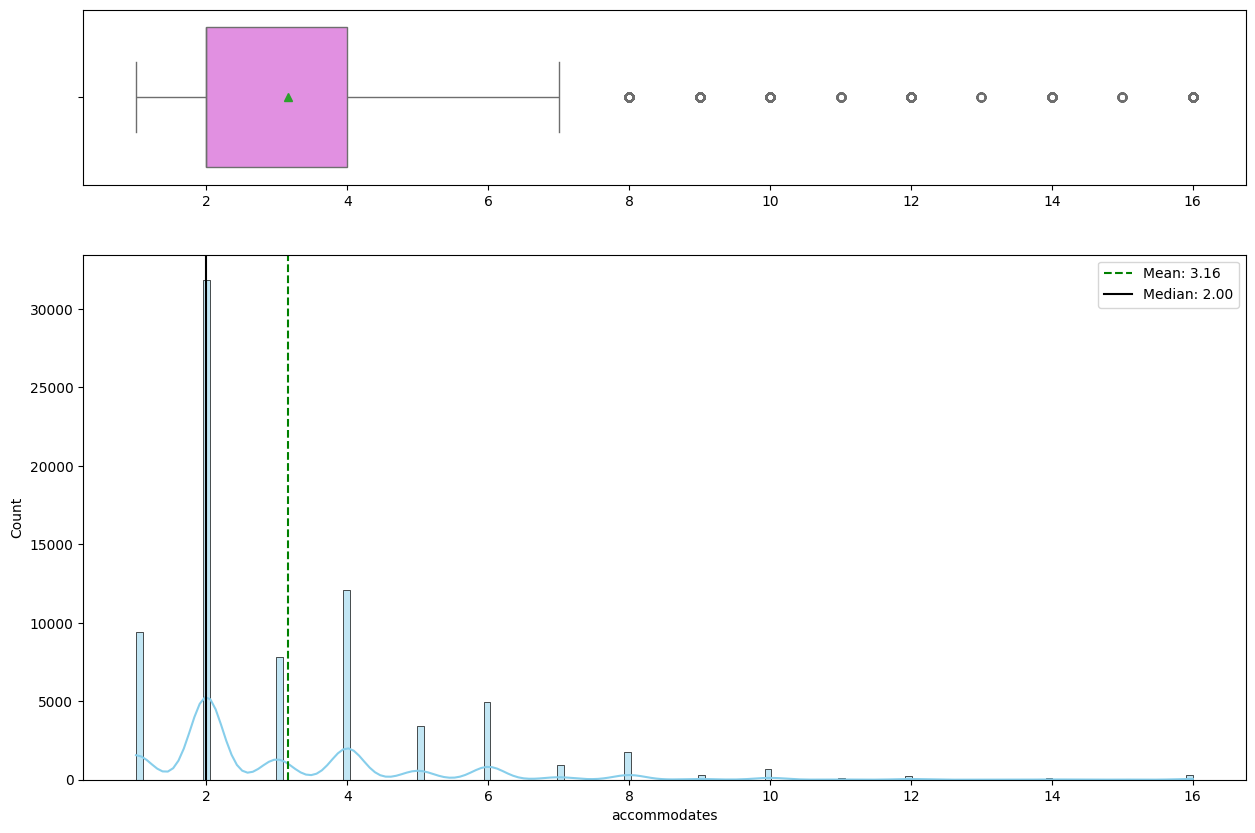

In [33]:
histogram_boxplot(data_17_filled['accommodates'])

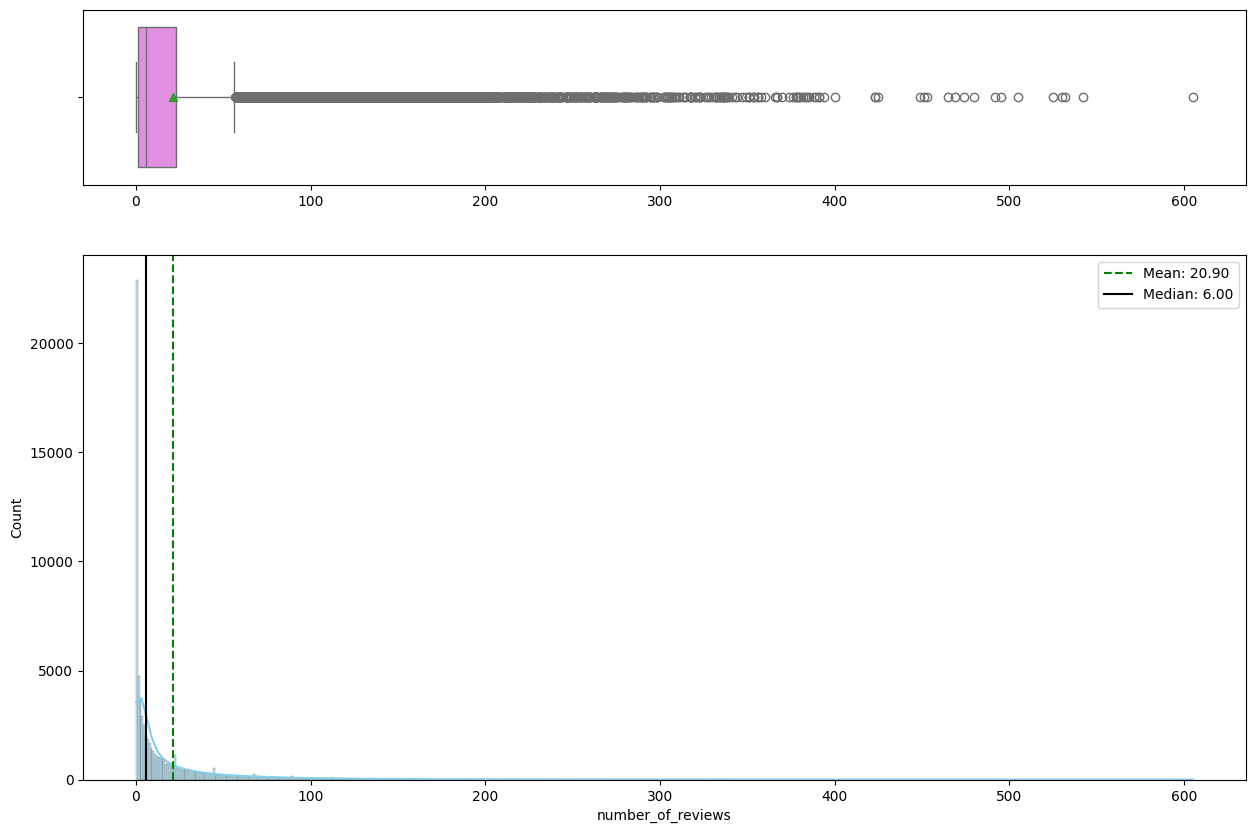

In [34]:
histogram_boxplot(data_17_filled['number_of_reviews'])

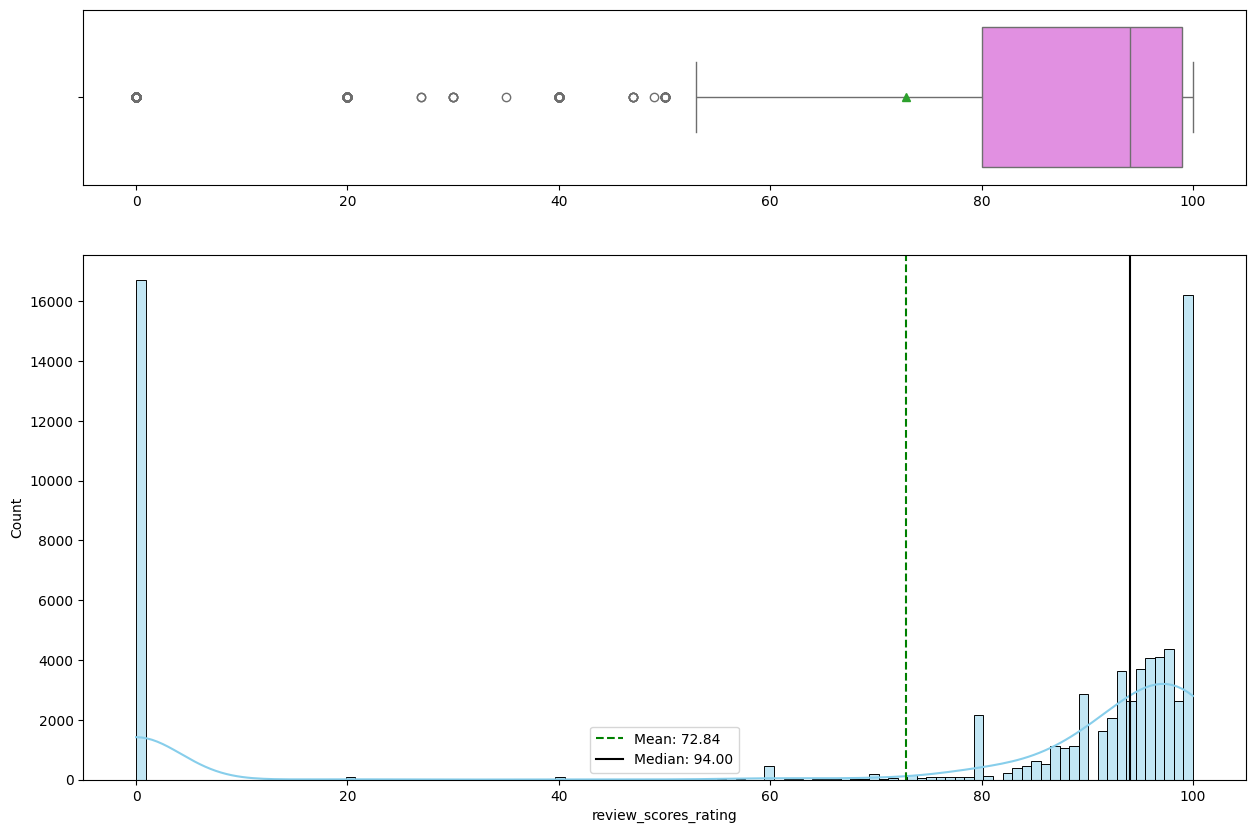

In [35]:
histogram_boxplot(data_17_filled['review_scores_rating'])

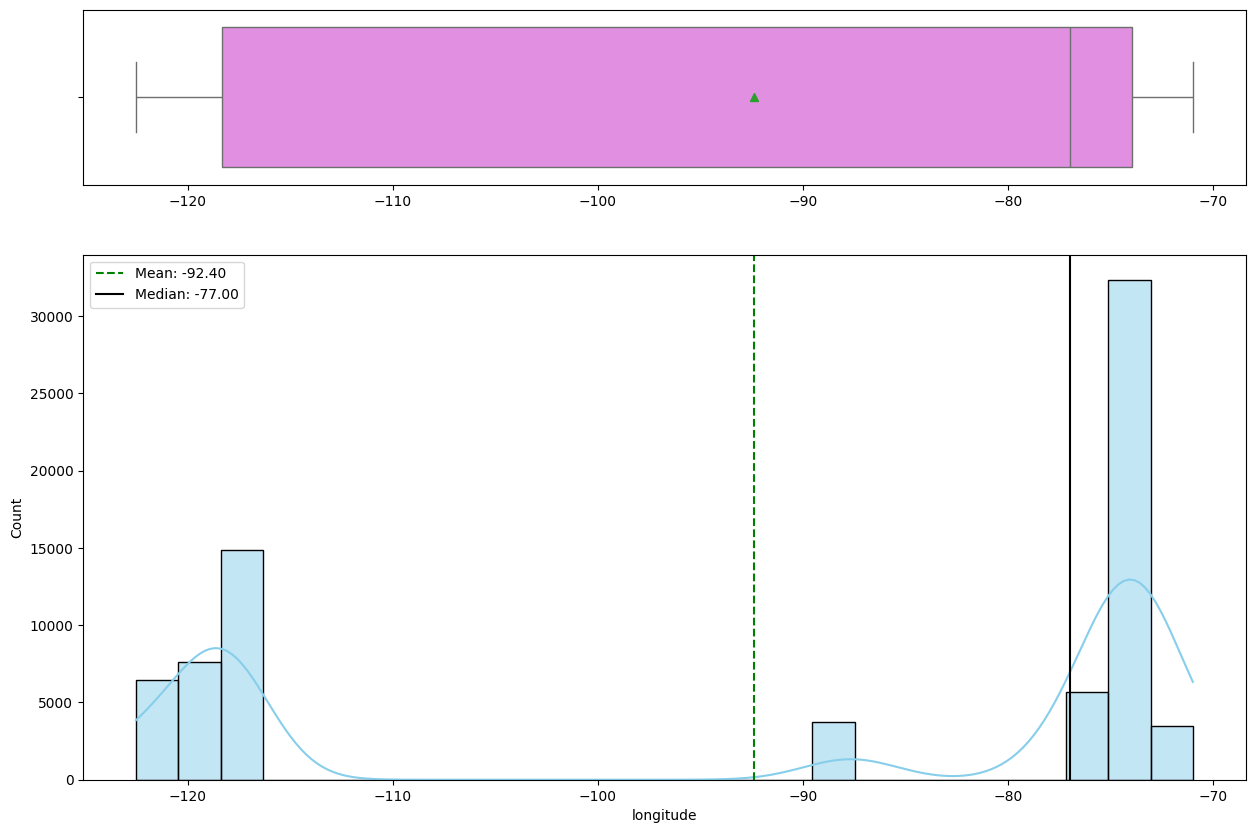

In [36]:
histogram_boxplot(data_17_filled['longitude'])

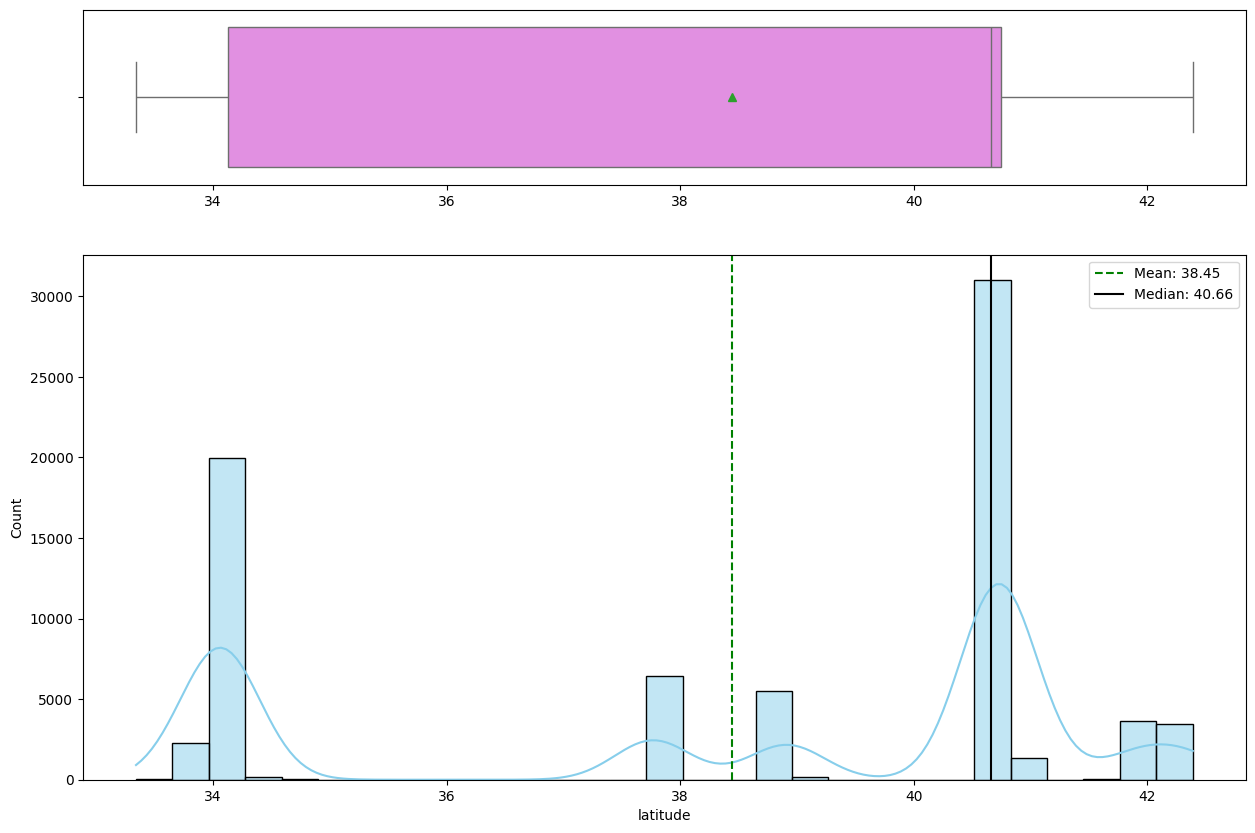

In [37]:
histogram_boxplot(data_17_filled['latitude'])

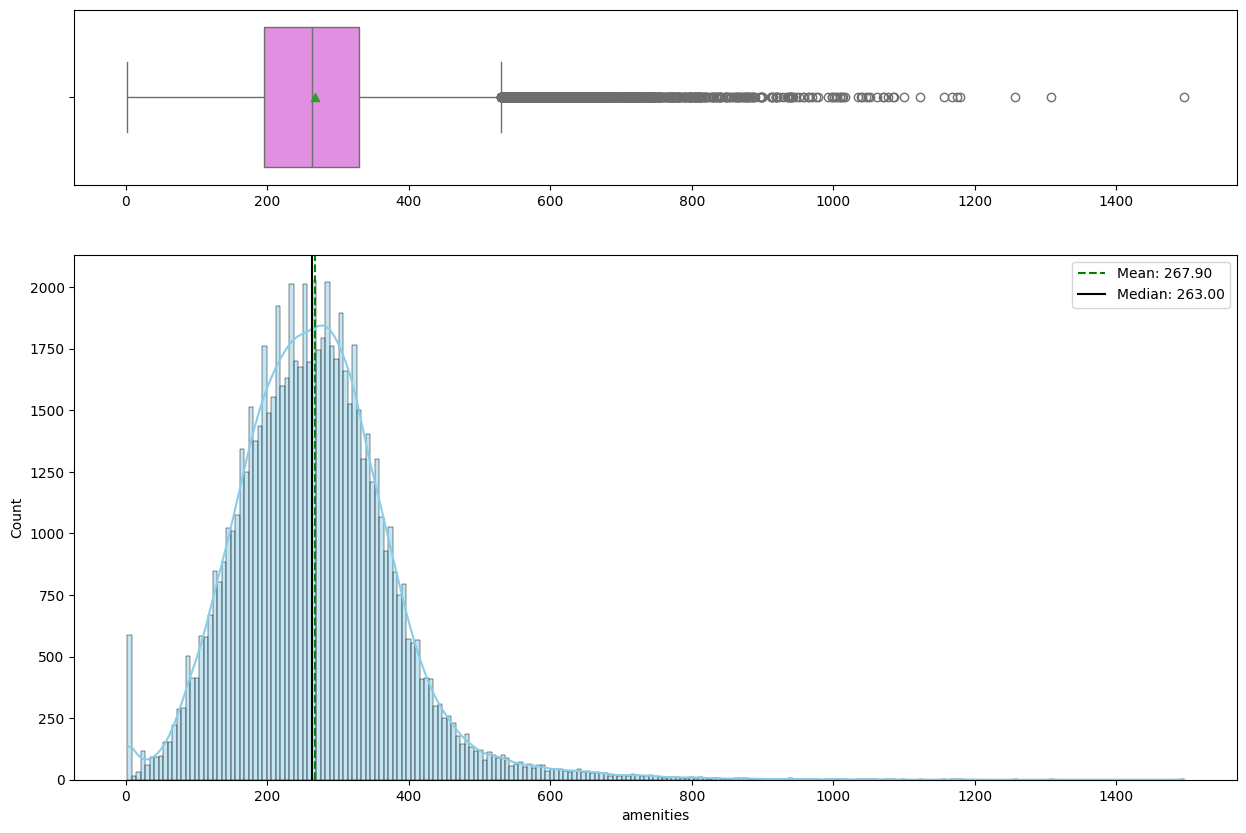

In [38]:
histogram_boxplot(data_17_filled['amenities'])

### Categorical

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

def countplot_piechart(feature, data, figsize=(18, 8), palette='Set2'):
    """
    Combined countplot and pie chart with consistent colors for categorical features.

    Parameters:
    - feature: Column name (categorical) as a string.
    - data: DataFrame containing the feature.
    - figsize: Figure size (default: (18, 8)).
    - palette: Color palette name or list of colors.
    """

    # Define subplot structure
    fig, (ax_count, ax_pie) = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=figsize,
        gridspec_kw={"width_ratios": (0.6, 0.4)}
    )

    # Ensure feature is treated as categorical (string) explicitly
    data[feature] = data[feature].astype(str)

    # Get ordered category counts
    feature_counts = data[feature].value_counts()

    # Create consistent color mapping
    colors = sns.color_palette(palette, len(feature_counts))
    color_mapping = dict(zip(feature_counts.index, colors))

    # Countplot with consistent colors
    sns.countplot(
        x=feature, 
        data=data, 
        palette=color_mapping, 
        ax=ax_count,
        order=feature_counts.index
    )

    total = len(data[feature])

    # Add percentage annotations to bars
    for p in ax_count.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax_count.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=13)

    ax_count.set_title(f'Countplot of {feature}', fontsize=16)
    ax_count.set_ylabel('Count', fontsize=14)
    ax_count.set_xlabel(feature, fontsize=14)
    ax_count.tick_params(axis='x', rotation=45)

    # Pie Chart with consistent colors
    ax_pie.pie(
        feature_counts,
        labels=feature_counts.index,
        autopct='%1.2f%%',
        colors=[color_mapping[label] for label in feature_counts.index],
        startangle=140,
        textprops={'fontsize': 13}
    )
    ax_pie.set_title(f'Pie Chart of {feature}', fontsize=16)
    ax_pie.axis('equal')  # Equal aspect ratio ensures the pie chart is circular.

    plt.tight_layout()
    plt.show()


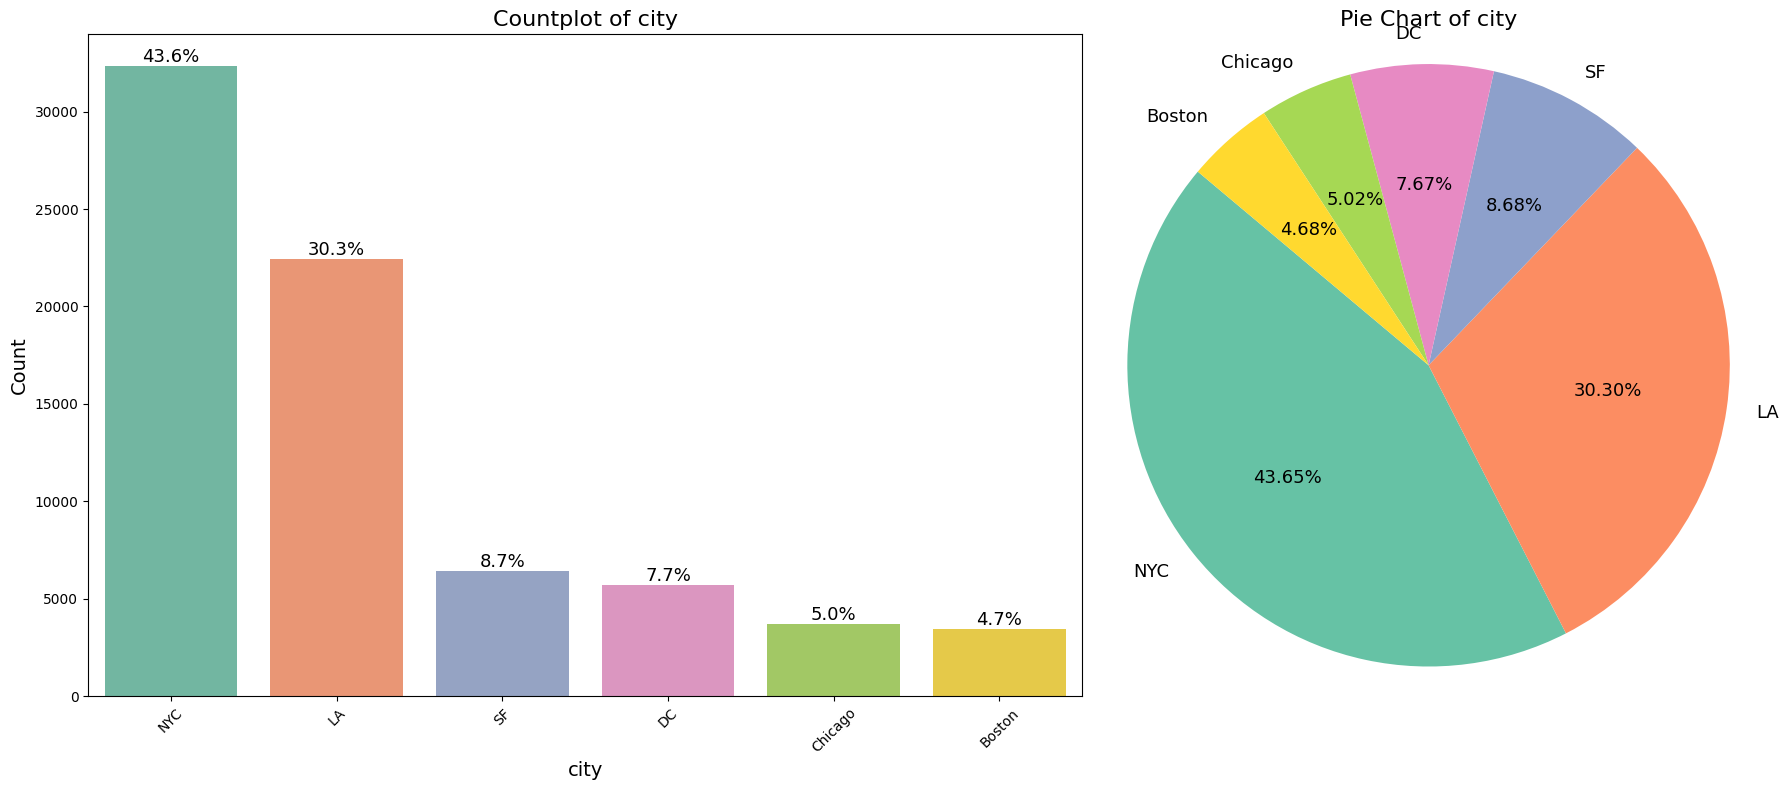

In [40]:
countplot_piechart('city', data_17_filled)

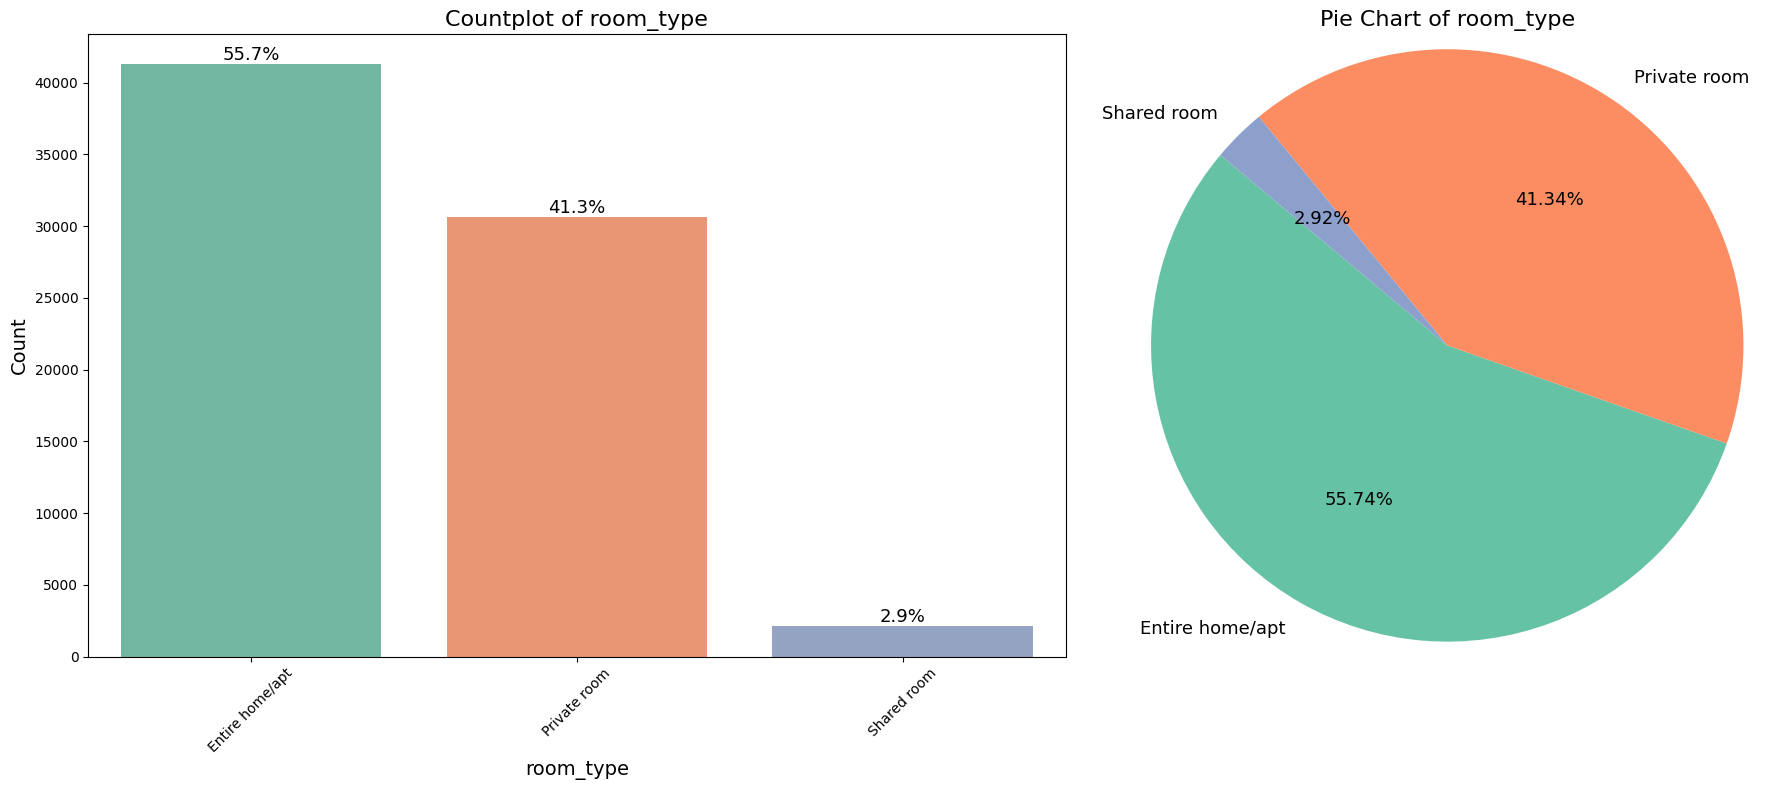

In [41]:
countplot_piechart('room_type', data_17_filled)

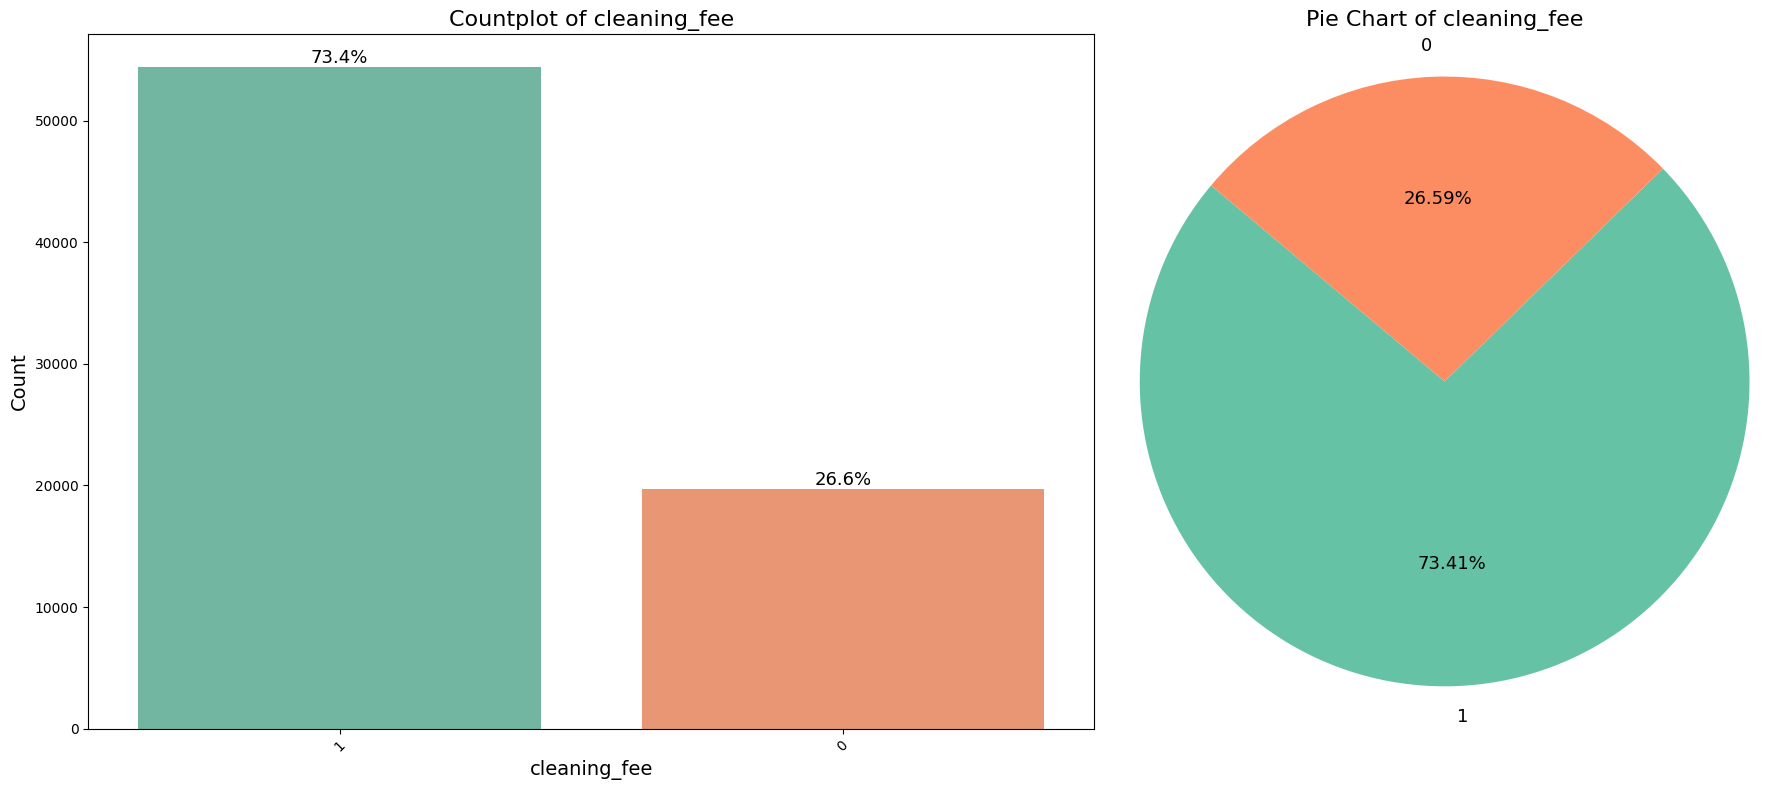

In [42]:
countplot_piechart('cleaning_fee', data_17_filled)

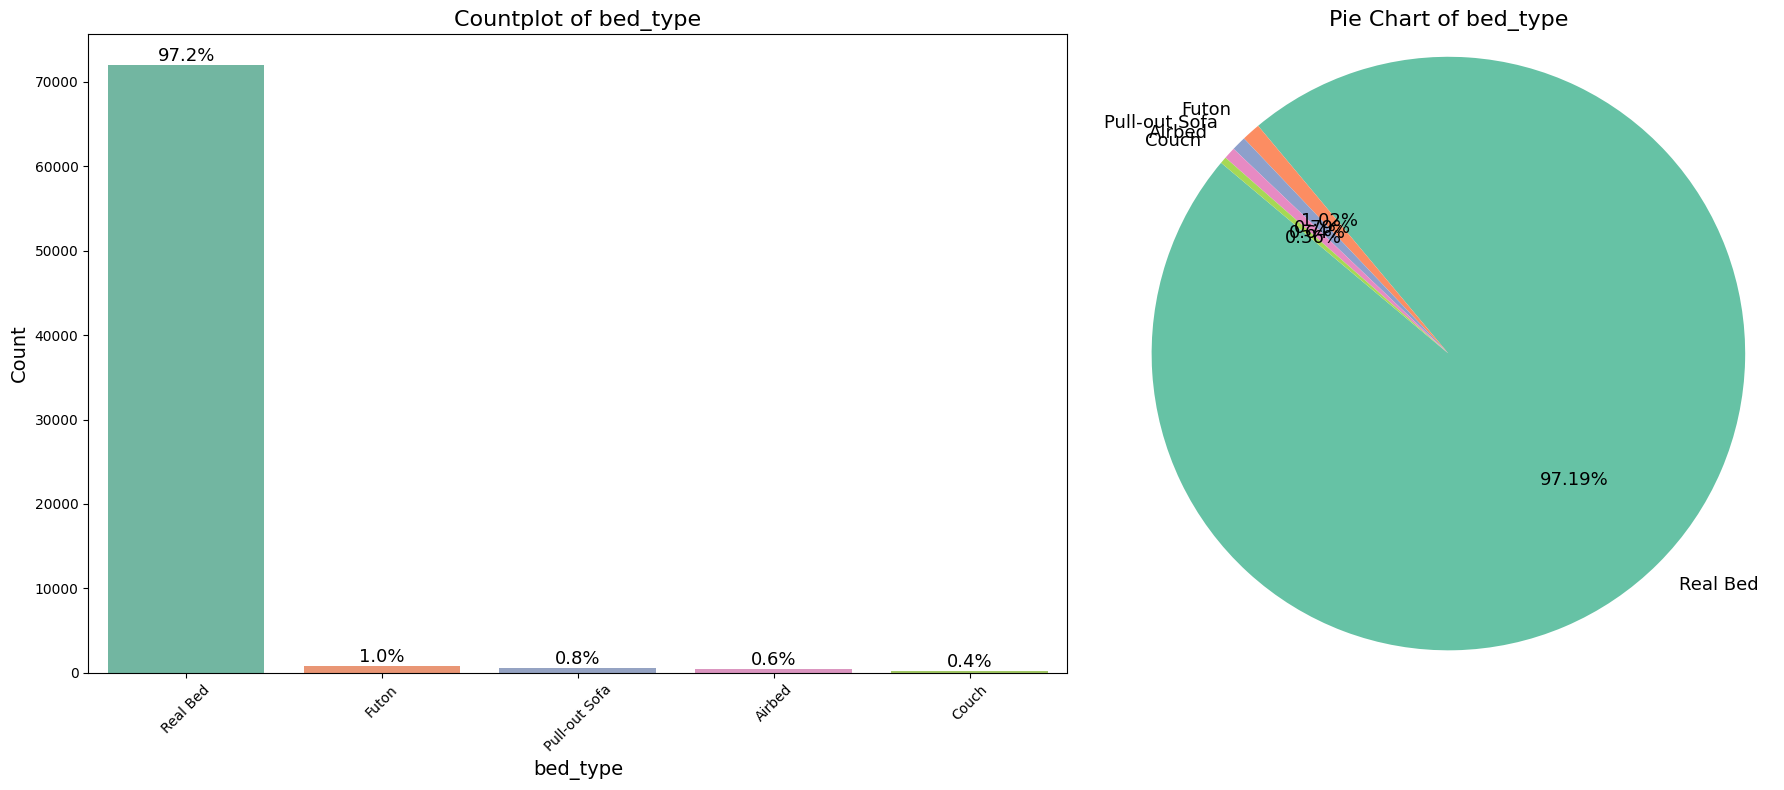

In [43]:
countplot_piechart('bed_type', data_17_filled)

#### Histogram plot for top 20 neighbourhoods

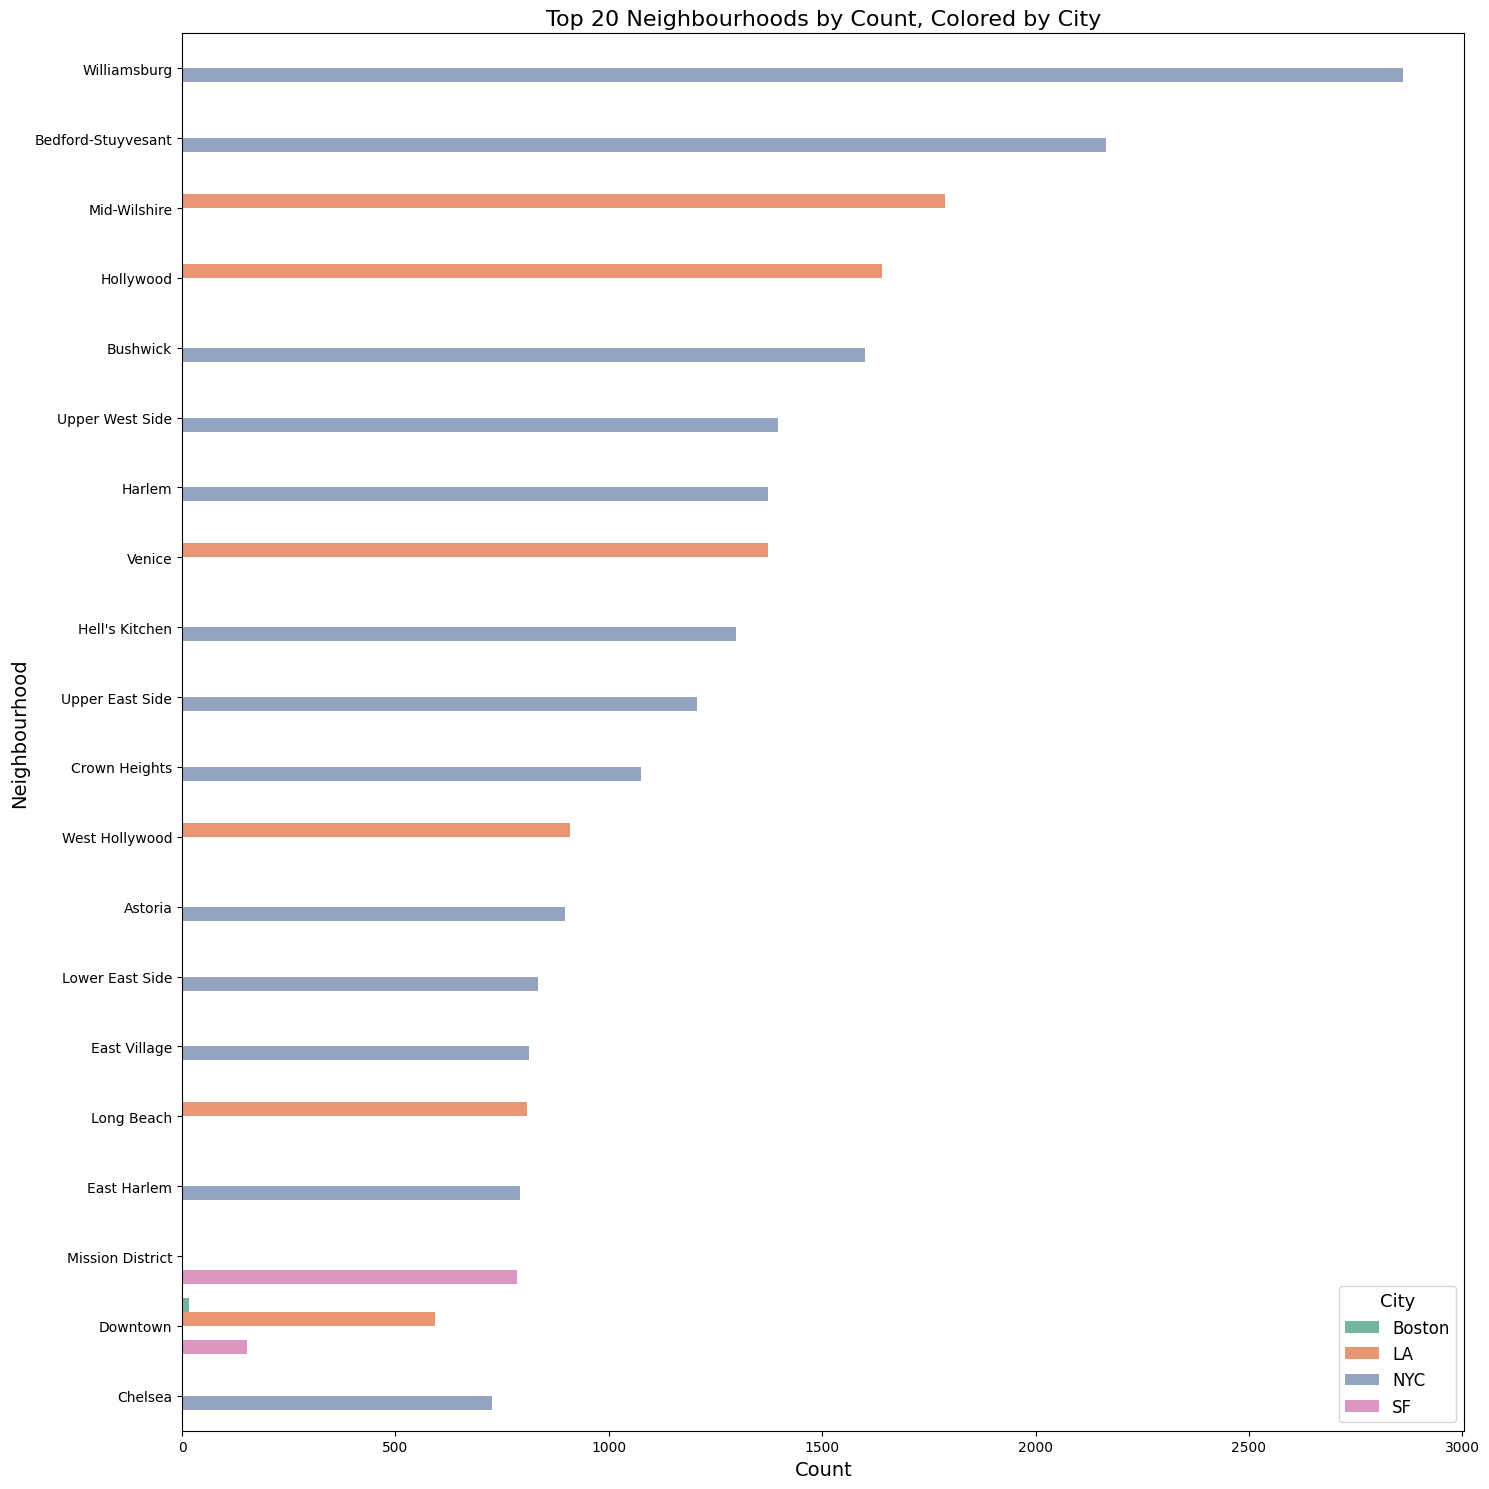

In [44]:
# Compute top 20 neighbourhoods by count
top_neighbourhoods = data_17_filled['neighbourhood'].value_counts().head(20).index

# Filter data to these top neighbourhoods
top_data = data_17_filled[data_17_filled['neighbourhood'].isin(top_neighbourhoods)]

# Order neighbourhoods by frequency
order = top_data['neighbourhood'].value_counts().index

# Plot
plt.figure(figsize=(15,15))
sns.countplot(
    data=top_data, 
    y='neighbourhood', 
    hue='city', 
    order=order, 
    palette='Set2'
)

plt.title('Top 20 Neighbourhoods by Count, Colored by City', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Neighbourhood', fontsize=14)
plt.legend(title='City', fontsize=12, title_fontsize=13, loc='best')

plt.tight_layout()
plt.show()


## Bivariate

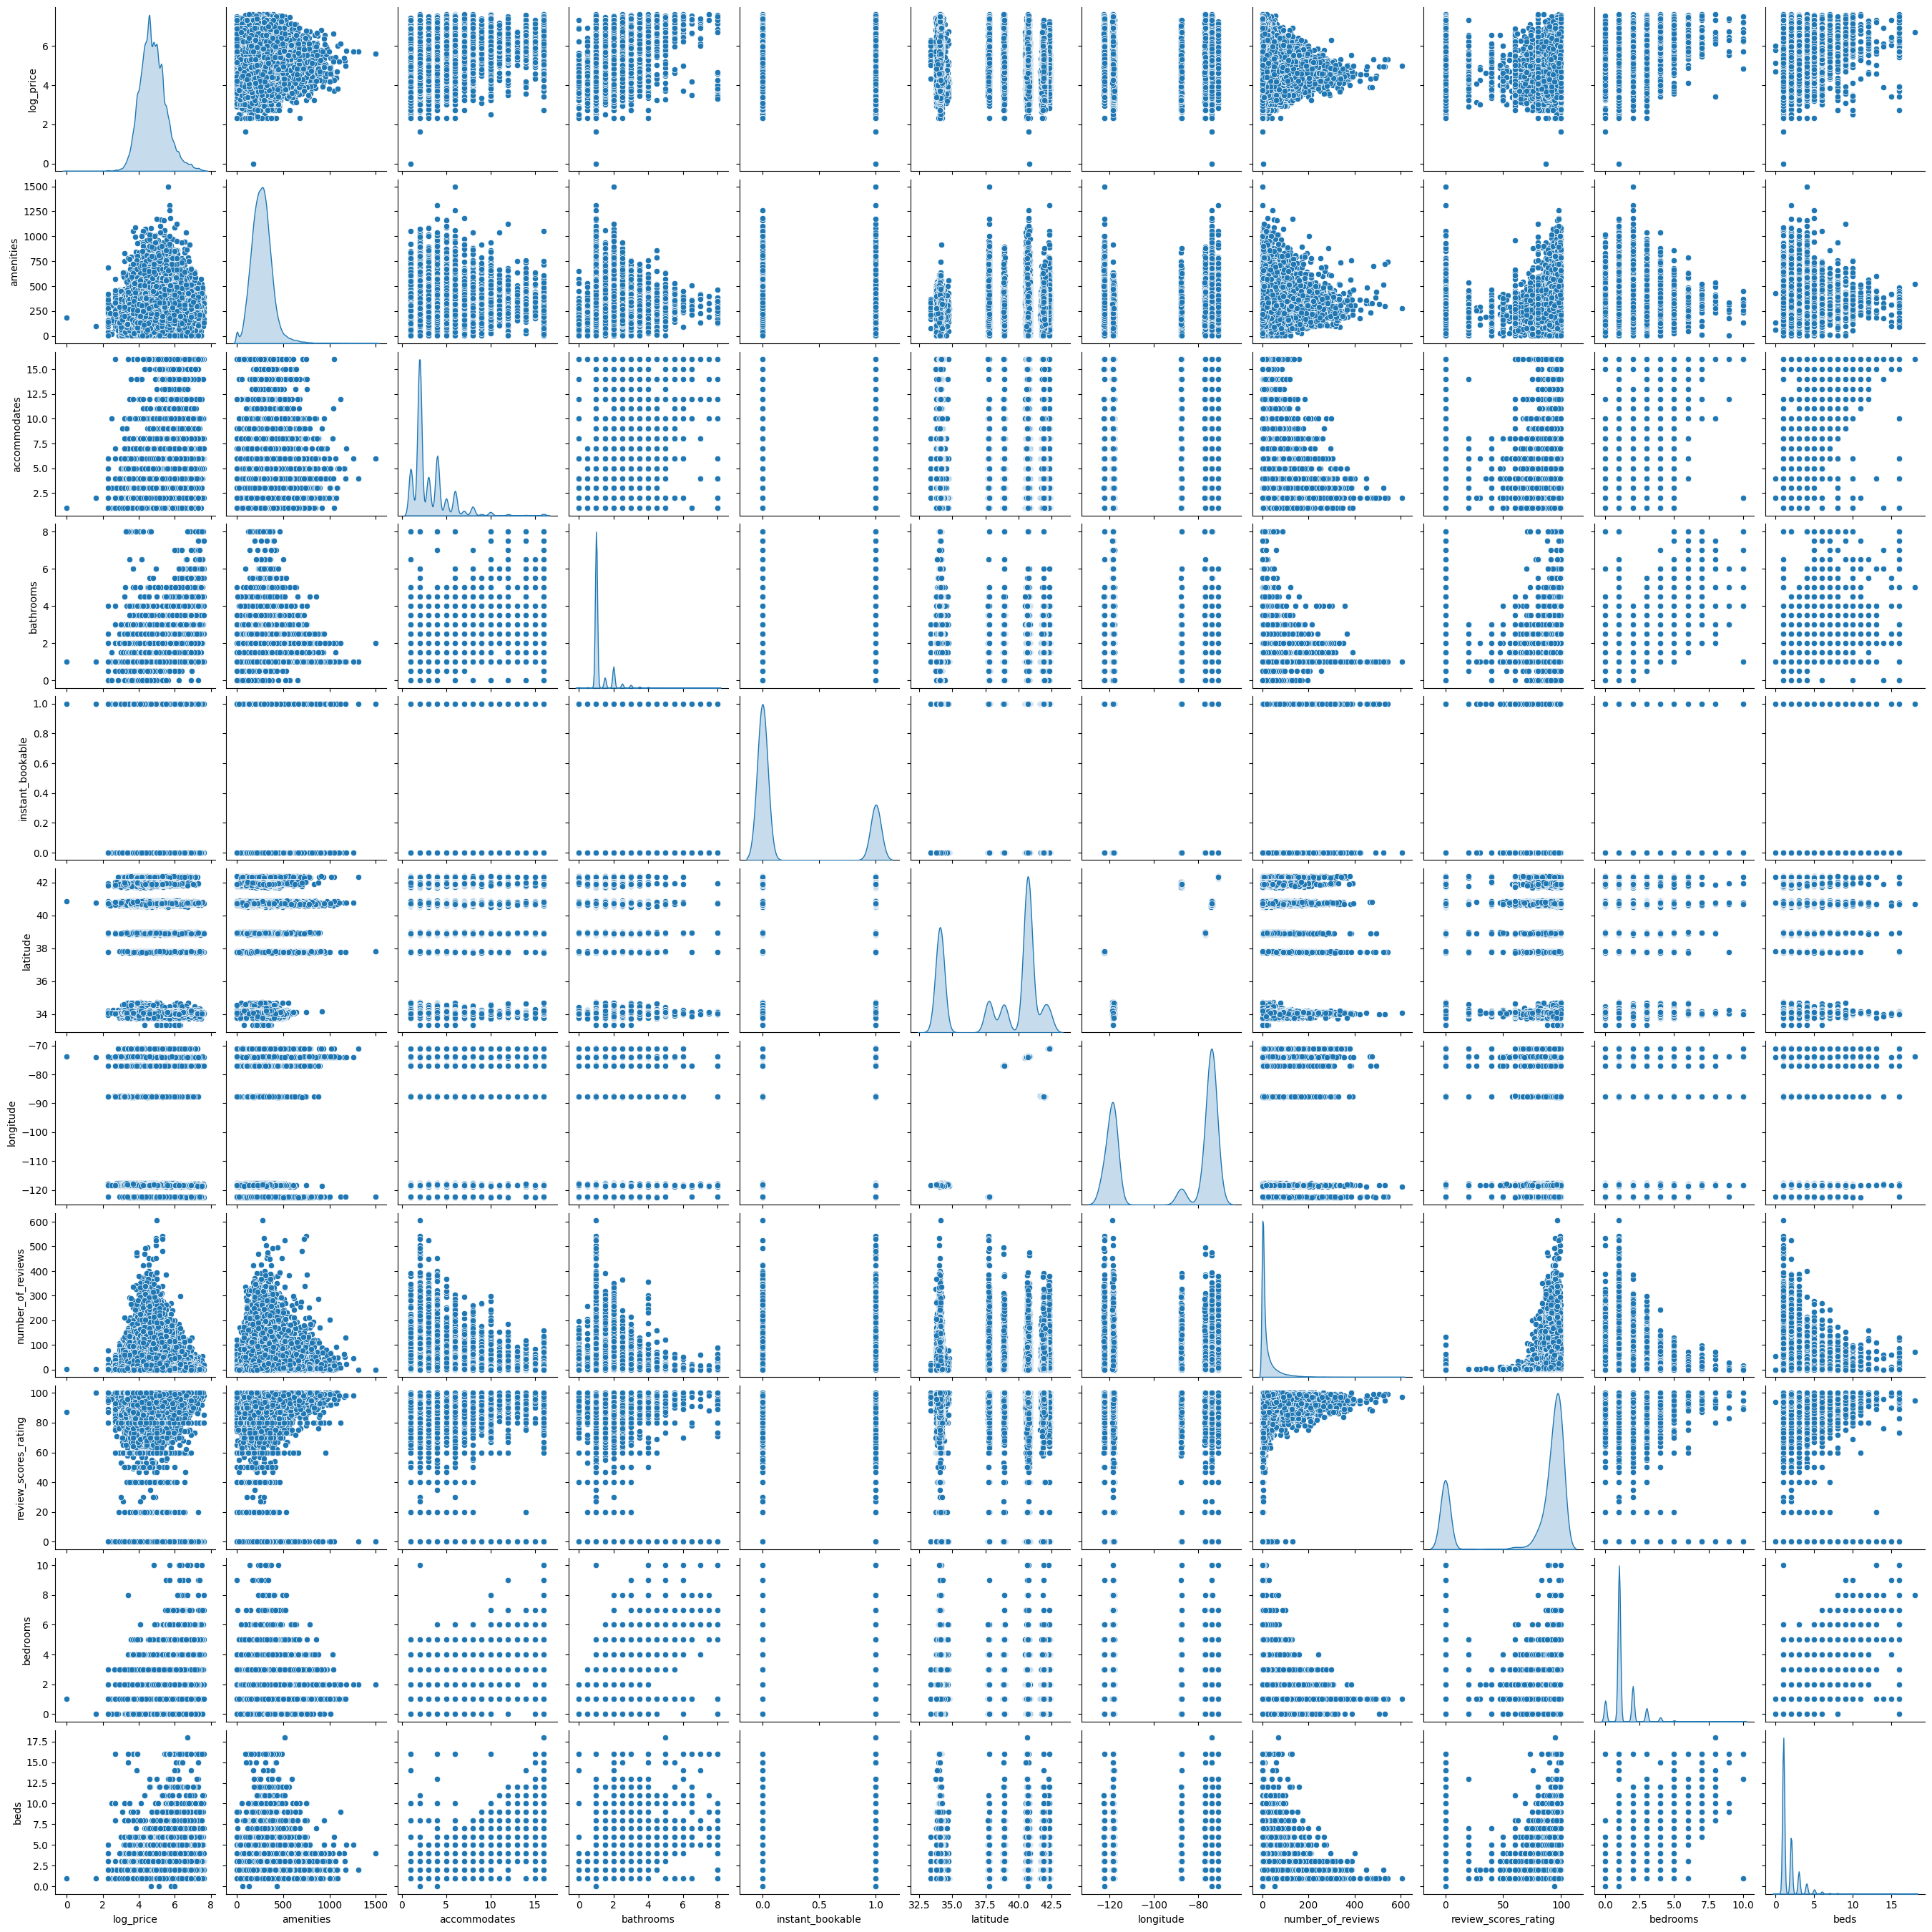

In [45]:
sns.pairplot(data_17_filled, diag_kind='kde')
plt.show()

In [46]:
def plot_boxplot(h,v):
    plt.figure(figsize=(15,8))
    sns.boxplot(data=data_17_filled, x=h, y=v,palette= 'Paired')
    plt.title('Density and distribution of prices ', fontsize=15)
    plt.xlabel(h)
    plt.ylabel(v)

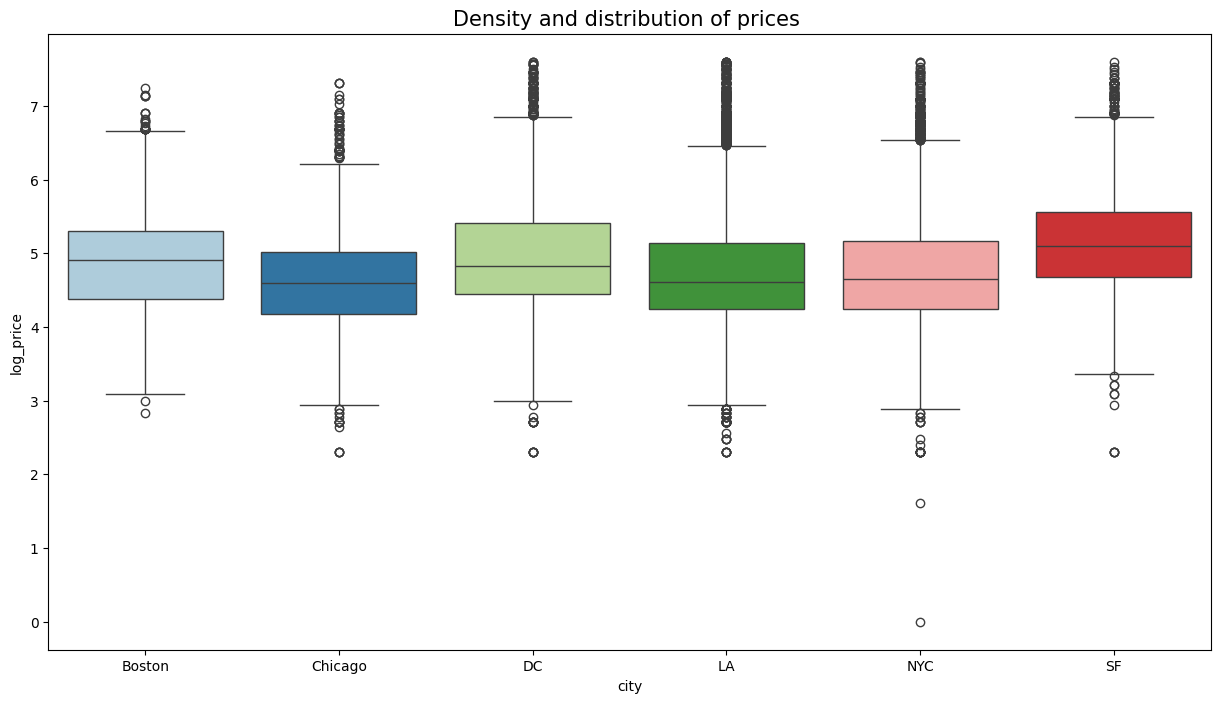

In [47]:
plot_boxplot("city","log_price")

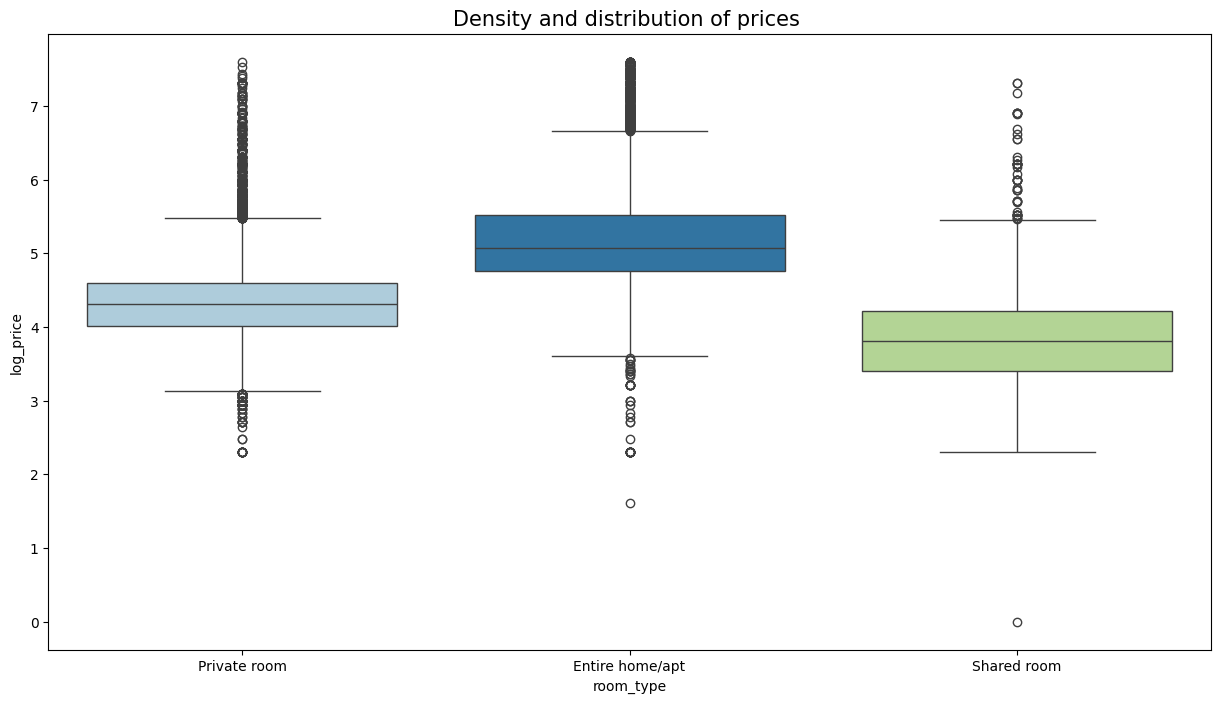

In [48]:
plot_boxplot("room_type","log_price")

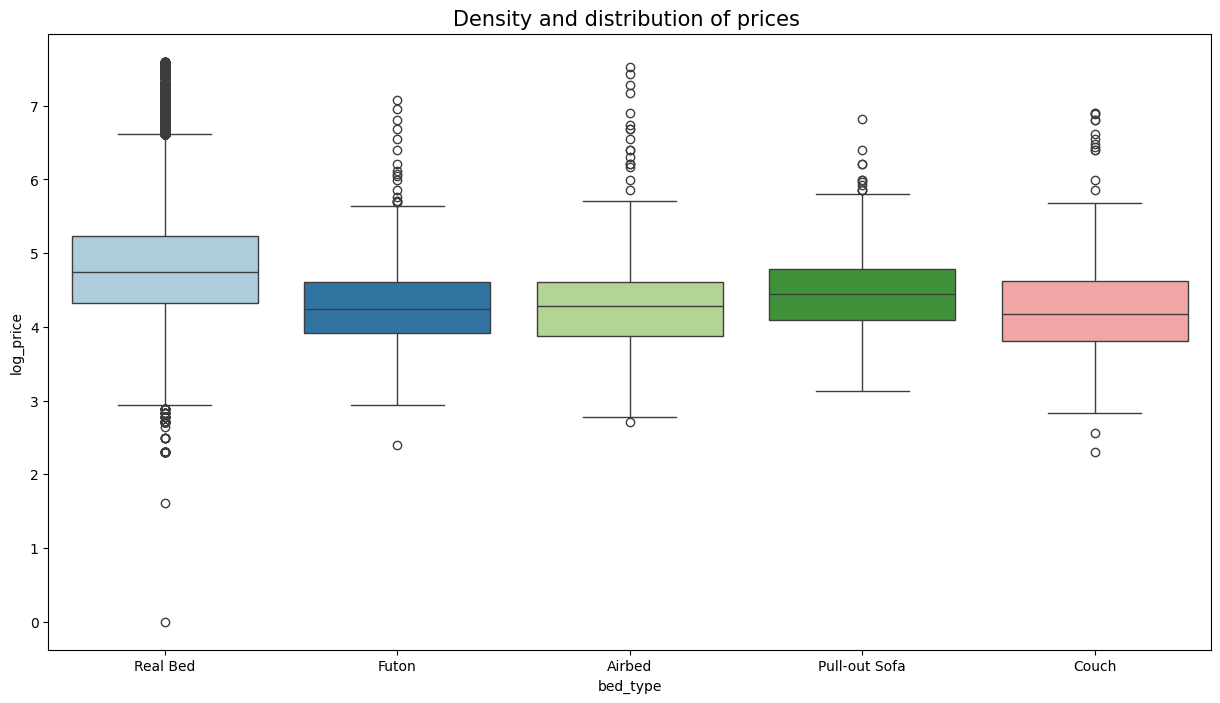

In [49]:
plot_boxplot("bed_type","log_price")

## Normal Assessment

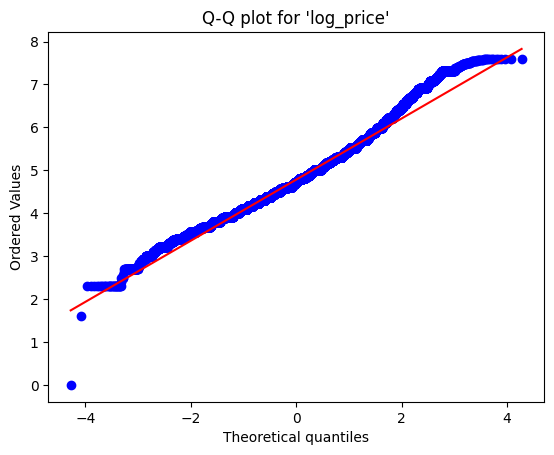

In [50]:
stats.probplot(data_17_filled['log_price'], dist="norm", plot=plt)
plt.title("Q-Q plot for 'log_price'")
plt.show()


Central Alignment:
The central portion of the data closely aligns with the red line, indicating the main body of the data approximately follows a normal distribution.

Upper Tail (right side):
There's a noticeable upward deviation from the straight line at the upper quantiles (top-right portion). This indicates right-skewness, suggesting that the higher prices in your dataset occur more frequently than expected if perfectly normally distributed.

Lower Tail (left side):
The lower quantiles (bottom-left) also show slight deviations, but they're less significant compared to the upper tail. This may imply some slight irregularities in lower-priced observations, possibly due to pricing cutoffs or minimal charges.

In [51]:
categorical_col = []
numerical_col = []
for column in data_17_filled.columns:
    
    if data_17_filled[column].dtypes != "float64" and data_17_filled[column].dtypes != "int64":
        categorical_col.append(column)
    else:
        numerical_col.append(column)

In [52]:
numerical_col

['log_price',
 'amenities',
 'accommodates',
 'bathrooms',
 'instant_bookable',
 'latitude',
 'longitude',
 'number_of_reviews',
 'review_scores_rating',
 'bedrooms',
 'beds']

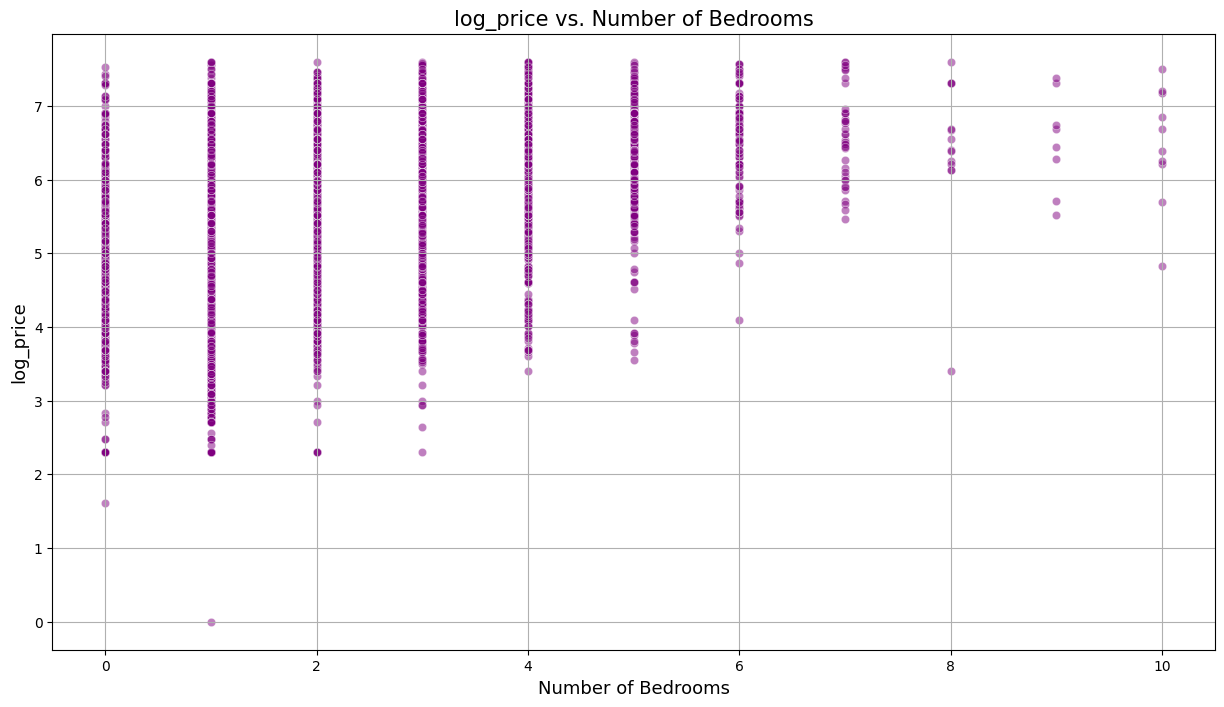

In [53]:
plt.figure(figsize=(15,8))
sns.scatterplot(x='bedrooms', y='log_price', data=data_17_filled, alpha=0.5, color='purple')
plt.title('log_price vs. Number of Bedrooms', fontsize=15)
plt.xlabel('Number of Bedrooms', fontsize=13)
plt.ylabel('log_price', fontsize=13)
plt.grid(True)
plt.show()

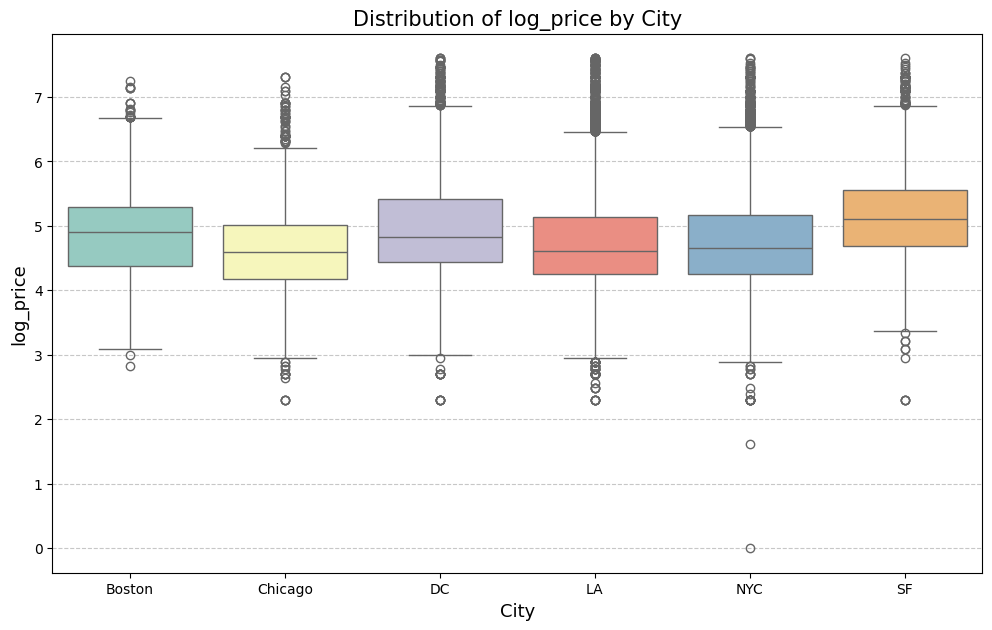

In [54]:
plt.figure(figsize=(12,7))
sns.boxplot(x='city', y='log_price', data=data_17_filled, palette='Set3')
plt.title('Distribution of log_price by City', fontsize=15)
plt.xlabel('City', fontsize=13)
plt.ylabel('log_price', fontsize=13)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

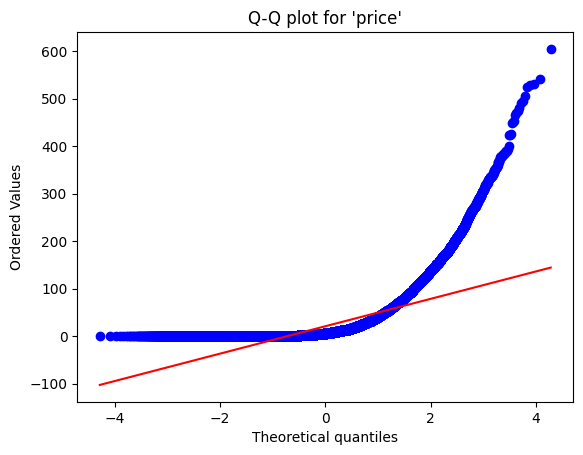

In [55]:
stats.probplot(data_17_filled['number_of_reviews'], dist="norm", plot=plt)
plt.title("Q-Q plot for 'price'")
plt.show()


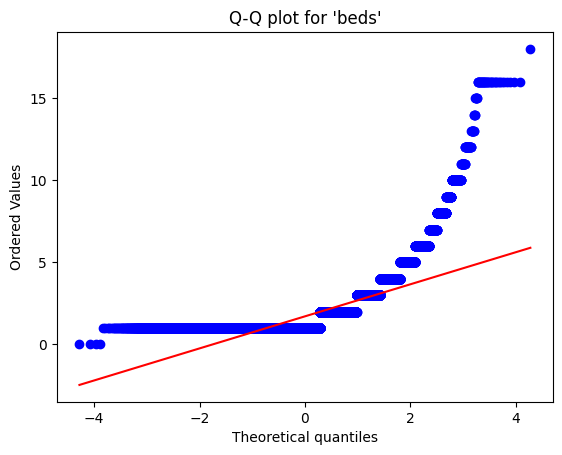

In [56]:
stats.probplot(data_17_filled['beds'], dist="norm", plot=plt)
plt.title("Q-Q plot for 'beds'")
plt.show()

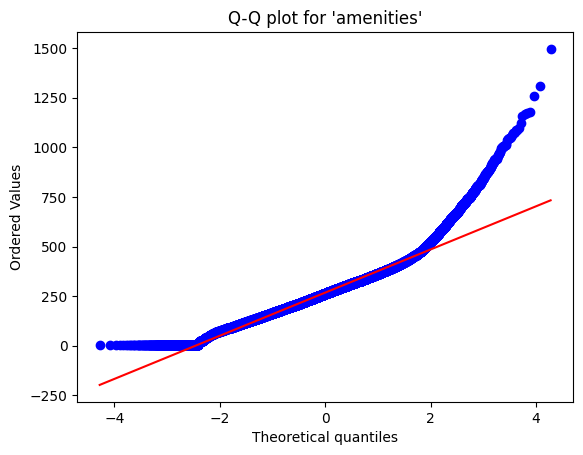

In [57]:
stats.probplot(data_17_filled['amenities'], dist="norm", plot=plt)
plt.title("Q-Q plot for 'amenities'")
plt.show()

## Parameter Estimation

In [ ]:
# List of numerical columns you want to analyze
numerical_cols = ['log_price', 'bedrooms', 'bathrooms', 'beds']  # replace with your desired numerical columns

# Population and sample size
population_data = data_17_filled[numerical_cols]
sample_data = population_data.sample(frac=0.1, random_state=42)  # Taking a 10% sample for demonstration

# Calculate statistics
summary_table = pd.DataFrame({
    'Mean': population_data.mean(),
    'Standard Deviation': population_data.std(ddof=0),  # Population SD
    'Variance': population_data.var(ddof=0),            # Population variance
    'Sample Mean': sample_data.mean(),
    'Sample SD': sample_data.std(ddof=1),               # Sample SD
    'Sample Variance': sample_data.var(ddof=1)          # Sample variance
})

# Display the table
summary_table


,Mean,Standard Deviation,Variance,Sample Mean,Sample SD,Sample Variance
log_price,4.782069,0.717389,0.514647,4.788248,0.720154,0.518622
bedrooms,1.265467,0.851665,0.725334,1.277425,0.863537,0.745697
bathrooms,1.234628,0.581382,0.338005,1.238362,0.578481,0.334640
beds,1.709611,1.253380,1.570962,1.738362,1.259227,1.585652


In [59]:
# List of numerical columns you want to analyze
numerical_cols = ['amenities']  # replace with your desired numerical columns

# Population and sample size
population_data = data_17_filled[numerical_cols]
sample_data = population_data.sample(frac=0.1, random_state=42)  # Taking a 10% sample for demonstration

# Calculate statistics
summary_table = pd.DataFrame({
    'Mean': population_data.mean(),
    'Standard Deviation': population_data.std(ddof=0),  # Population SD
    'Variance': population_data.var(ddof=0),            # Population variance
    'Sample Mean': sample_data.mean(),
    'Sample SD': sample_data.std(ddof=1),               # Sample SD
    'Sample Variance': sample_data.var(ddof=1)          # Sample variance
})

# Display the table
summary_table


,Mean,Standard Deviation,Variance,Sample Mean,Sample SD,Sample Variance
amenities,267.897654,111.053973,12332.98491,267.59749,109.370024,11961.802202


In [60]:
# List of categorical columns you want to analyze
categorical_cols = ['city', 'neighbourhood', 'cleaning_fee']  # Replace with your categorical columns

# Population and sample data
population_data = data_17_filled[categorical_cols]
sample_data = population_data.sample(frac=0.1, random_state=42)  # Taking a 10% sample for demonstration

# Creating a summary dictionary
summary_dict = {}

for col in categorical_cols:
    # Calculate population counts and proportions
    pop_counts = population_data[col].value_counts()
    pop_proportions = population_data[col].value_counts(normalize=True).mul(100).round(2)
    
    # Calculate sample proportions
    samp_proportions = sample_data[col].value_counts(normalize=True).mul(100).round(2)
    
    # Combine into a DataFrame
    summary_df = pd.DataFrame({
        'Population Count': pop_counts,
        'Population Proportion (%)': pop_proportions,
        'Sample Proportion (%)': samp_proportions
    }).fillna(0)  # Handle cases where categories might not appear in sample
    
    summary_dict[col] = summary_df

# Display summary tables
for col, df_summary in summary_dict.items():
    print(f"\nCategorical Variable: {col}\n")
    print(df_summary.head(10))  # showing top 10 categories for readability



Categorical Variable: city

         Population Count  Population Proportion (%)  Sample Proportion (%)
city                                                                       
NYC                 32349                      43.65                  43.19
LA                  22453                      30.30                  30.77
SF                   6434                       8.68                   8.72
DC                   5688                       7.67                   7.85
Chicago              3719                       5.02                   4.90
Boston               3468                       4.68                   4.57

Categorical Variable: neighbourhood

                     Population Count  Population Proportion (%)  \
neighbourhood                                                      
16th Street Heights               101                       0.14   
Adams Morgan                      239                       0.32   
Alamo Square                       97                

In [61]:
# Create a copy of your original dataframe
data_17_filled_normalized = data_17_filled.copy()

# Identify numerical columns excluding the dependent variable 'log_price'
numerical_cols = data_17_filled_normalized.select_dtypes(include=['float64', 'int64']).columns
numerical_cols_to_normalize = numerical_cols.drop('log_price')

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Normalize only independent numerical columns
data_17_filled_normalized[numerical_cols_to_normalize] = scaler.fit_transform(
    data_17_filled_normalized[numerical_cols_to_normalize]
)

# Check the result
data_17_filled_normalized.head()


,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cleaning_fee,city,instant_bookable,latitude,longitude,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,4.595120,Townhouse,Private room,0.210843,0.066667,0.250,Real Bed,1,Boston,0.0,0.994339,0.998746,South Boston,0.019835,0.88,02127,0.1,0.055556
1,4.682131,Condominium,Private room,0.254351,0.066667,0.125,Real Bed,1,Boston,1.0,0.993392,0.998678,South Boston,0.066116,0.96,02127,0.1,0.055556
2,4.828314,Apartment,Entire home/apt,0.244311,0.333333,0.125,Real Bed,1,Boston,0.0,0.993987,0.998683,South Boston,0.008264,1.00,02127,0.2,0.222222
3,4.094345,House,Private room,0.117135,0.066667,0.125,Real Bed,0,Boston,0.0,0.992137,0.997512,Jamaica Plain,0.000000,0.00,02130,0.1,0.055556
4,4.962845,Apartment,Entire home/apt,0.147925,0.066667,0.125,Real Bed,0,Boston,1.0,0.996328,0.998320,Beacon Hill,0.003306,0.80,02114,0.1,0.055556


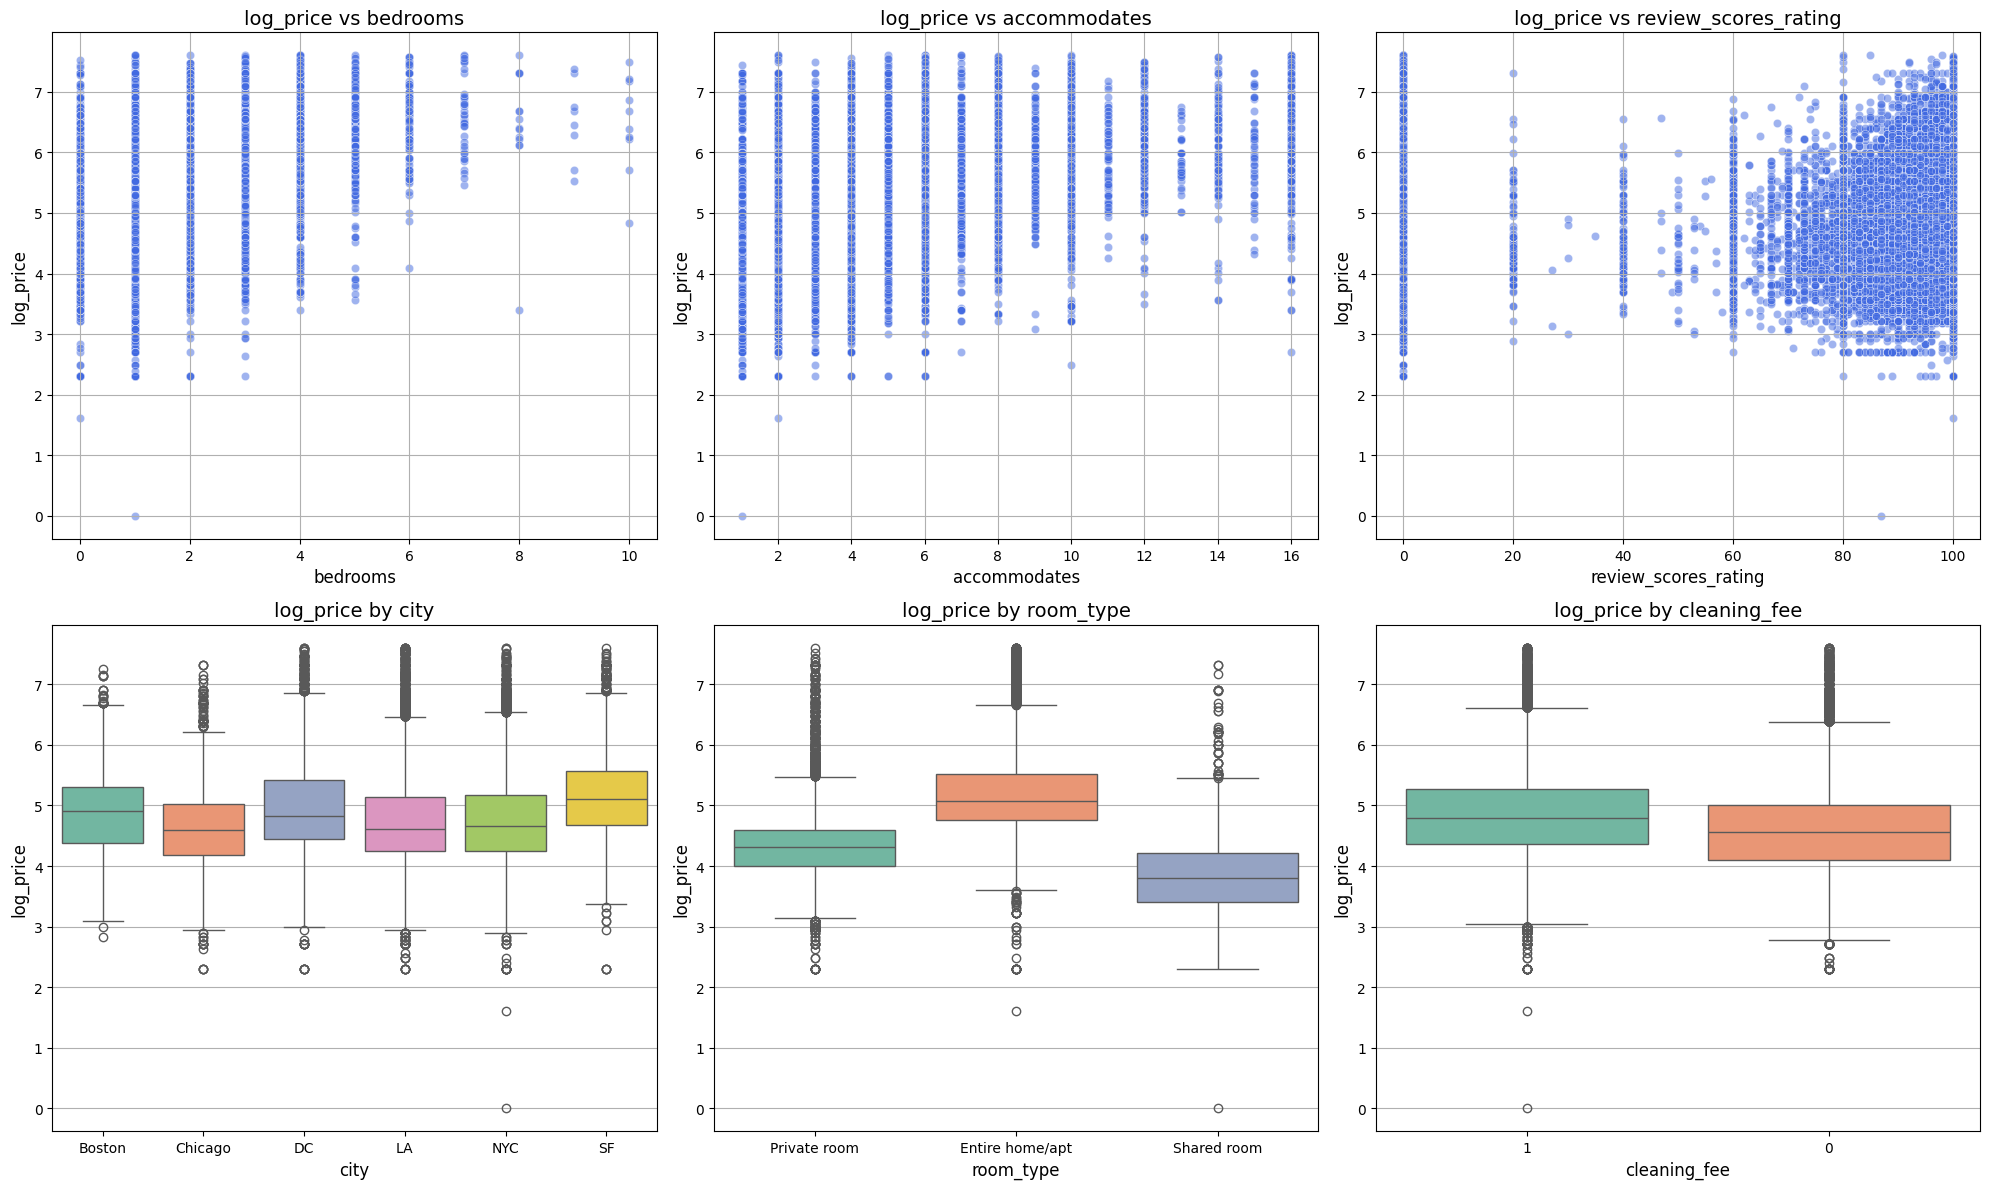

In [62]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))

# Numerical columns (Scatter plots)
numerical_cols = ['bedrooms', 'accommodates', 'review_scores_rating']
for ax, col in zip(axes[0], numerical_cols):
    sns.scatterplot(x=col, y='log_price', data=data_17_filled, ax=ax, alpha=0.5, color='royalblue')
    ax.set_title(f'log_price vs {col}', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('log_price', fontsize=12)
    ax.grid(True)

# Categorical columns (Box plots)
categorical_cols = ['city', 'room_type', 'cleaning_fee']
for ax, col in zip(axes[1], categorical_cols):
    sns.boxplot(x=col, y='log_price', data=data_17_filled, ax=ax, palette='Set2')
    ax.set_title(f'log_price by {col}', fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('log_price', fontsize=12)
    ax.grid(True, axis='y')

plt.tight_layout()
plt.show()


Part 2 Statistical Analysis

In [63]:
# Randomly select 100 samples
sampled_data = data_17_filled.sample(n=100, random_state=42) # random_state ensures reproducibility
print(sampled_data.shape)
sampled_data.head()

(100, 18)


,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cleaning_fee,city,instant_bookable,latitude,longitude,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
4079,4.595120,Apartment,Entire home/apt,220,5,1.0,Real Bed,0,Chicago,0,41.963513,-87.667056,Uptown,30,96.0,60640,1.0,2.0
33735,5.356586,Apartment,Entire home/apt,215,4,1.0,Real Bed,1,LA,1,34.067874,-118.381125,Beverly Hills,6,90.0,90048,1.0,2.0
69475,4.574711,Loft,Entire home/apt,21,16,1.0,Real Bed,0,SF,0,37.774859,-122.497928,Richmond District,23,87.0,94121,1.0,1.0
454,4.158883,House,Private room,368,2,1.0,Real Bed,1,Boston,0,42.361725,-71.127162,Allston-Brighton,34,96.0,02134,1.0,1.0
25153,4.094345,Townhouse,Private room,273,2,1.0,Real Bed,1,LA,0,33.829652,-118.300265,Harbor Gateway,2,100.0,90501,1.0,1.0


1. Randomly select 100 samples from your variables, design a proper
hypothesis, perform the following analysis, and interpret your results. Claim
(2.5+2.5 points for mean=C (your guess) and proportion=0.5), Hypothesis
test (2.5+2.5 points), CI (2.5+2.5 points), Interpret (2.5+2.5 points) the
proportion, and mean of your variable. (20 points)

Variable Selection: For the first test I choose variable "accommodates" for the mean test and  categorical/binary variable "cleaning_fee" which is mapped to 0/1 for the proportion test from our sampled_data.   


---------------------------------------------------------------------------------------------------------------------------------------

Mean Test (accommodates):

Claim & Hypothesis: The average number of people an Airbnb listing accommodates is 3. 

Formulate Null (H₀: μ = 3) 
Alternative (H₁: μ ≠ 3) hypotheses.

Test: Use a one-sample t-test (since population SD is likely unknown).

In [64]:
import scipy.stats as stats

t_statistic, p_value_mean = stats.ttest_1samp(sampled_data['accommodates'], 3)
print(f"T-statistic: {t_statistic}, P-value: {p_value_mean}")

T-statistic: 1.406974168018031, P-value: 0.1625667056775136


CI: Calculate the confidence interval for the mean.

In [65]:
confidence_level = 0.95
degrees_freedom = len(sampled_data['accommodates']) - 1
sample_mean = sampled_data['accommodates'].mean()
sample_std_err = stats.sem(sampled_data['accommodates'])

ci_mean = stats.t.interval(confidence_level, degrees_freedom, loc=sample_mean, scale=sample_std_err)
print(f"Confidence Interval for mean: {ci_mean}")

Confidence Interval for mean: (np.float64(2.8810209803296516), np.float64(3.6989790196703485))


The p-value (0.163) is greater than the significance level of 0.05, so we fail to reject the null hypothesis. This means that there is not enough statistical evidence to conclude that the true mean number of people an Airbnb listing accommodates is different from 3.

Additionally, the 95% confidence interval for the mean is (2.88, 3.70), which includes the value 3, further supporting the decision to fail to reject the null hypothesis.

---------------------------------------------------------------------------------------------------------------------------------------

Proportion Test (cleaning_fee):

Claim & Hypothesis: We claim that 50% of the Airbnb listings include a cleaning fee. 

Formulate Null (H₀: p = 0.5) 
Alternative (H₁: p ≠ 0.5) hypotheses.

Test: Use a one-proportion z-test (appropropriate for n=100).

In [69]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

count = sampled_data['cleaning_fee'].astype(int).sum() # Number of successes (cleaning fee charged)
nobs = len(sampled_data['cleaning_fee']) # Total observations
value = 0.5 # Hypothesized proportion

z_stat, p_value_prop = proportions_ztest(count, nobs, value)
print(f"Z-statistic: {z_stat}, P-value: {p_value_prop}")

Z-statistic: 7.119914934033427, P-value: 1.0799369474824134e-12


CI: Calculate the confidence interval for the proportion

In [70]:
ci_prop = proportion_confint(count, nobs, alpha=0.05, method='normal') 
print(f"Confidence Interval for proportion: {ci_prop}")

Confidence Interval for proportion: (0.7101690524700379, 0.8698309475299622)


Conclusion:
The P-value is extremely small and well below the significance level of 0.05. This indicates that the probability of observing a sample proportion this far from 0.5 (if the true population proportion were actually 0.5) is nearly zero. Therefore, we reject the null hypothesis.

Additionally, the 95% confidence interval for the true proportion lies between 71.0% and 87.0%, which does not include 0.5. This further supports our conclusion.

Interpretation:
Based on the sample of 100 listings, there is strong statistical evidence that the true proportion of listings charging a cleaning fee is different from 0.5. We are 95% confident that this proportion lies between 71.0% and 87.0%, suggesting that a significantly higher percentage of listings apply a cleaning fee.

---------------------------------------------------------------------------------------------------------------------------------------

2. Use samples from your other variables and compare two sample means and
SD. Submit your results of the following hypothesis test (2.5+2.5 points), b.
CI (2.5+2.5 points) for your variable, Interpret your results (2.5+2.5 points).
(15 points)

We will be comparing means and standard deviations (SD) of two other sample variables using hypothesis tests, CIs, and interpretation for this question. 

Variables: "log_price" (target variable) between two "room_type" categories (e.g., 'Entire home/apt' vs 'Private room'). We've already label-encoded room_type, so we'll need to map those back or filter the sample before encoding.   

Data Prep: Create two separate series/arrays containing log_price for each room type group from sampled_data. Let's call them price_entire and price_private.

Hypothesis (Means):
H₀: μ_entire = μ_private, 
H₁: μ_entire ≠ μ_private.

Test (Means): Use an independent two-sample t-test. First, check for equal variances (optional but good practice).

In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.stats.weightstats as sms 

# Filter log_price based on the actual string values in 'room_type'
price_entire = sampled_data[sampled_data['room_type'] == 'Entire home/apt']['log_price']
price_private = sampled_data[sampled_data['room_type'] == 'Private room']['log_price']

print(f"Number of Entire home/apt samples: {len(price_entire)}")
print(f"Number of Private room samples: {len(price_private)}")
print("-" * 30)

# Check for NaN values in both groups
price_entire_clean = price_entire.dropna()
price_private_clean = price_private.dropna()

# Check if enough data points remain after dropping NaNs
if len(price_entire_clean) < 2 or len(price_private_clean) < 2:
    print("Not enough data points in one or both groups after removing NaNs to perform tests.")
else:
    # Test for equal variances (Levene's test)
    levene_stat, levene_p = stats.levene(price_entire_clean, price_private_clean)
    equal_var_flag = levene_p > 0.05 # If True, assume equal variances

    print(f"Levene's test statistic: {levene_stat:.4f}, P-value: {levene_p:.4f}")

    if not equal_var_flag:
        print("Variances are likely unequal (p <= 0.05).")
        use_variance_sm = 'unequal' # For statsmodels CI
    else:
        print("Variances are likely equal (p > 0.05).")
        use_variance_sm = 'pooled' # For statsmodels CI
    print("-" * 30)

    # --- T-test (using scipy.stats as in your original code) ---
    t_stat_2samp, p_value_2samp = stats.ttest_ind(price_entire_clean, price_private_clean, equal_var=equal_var_flag)
    print(f"T-test Results (scipy.stats):")
    print(f"T-statistic: {t_stat_2samp:.4f}, P-value: {p_value_2samp:.4f}")
    print("-" * 30)

    # --- Confidence Interval for the Difference in Means (using statsmodels) ---
    print(f"Confidence Interval Calculation (statsmodels):")
    # Set confidence level
    alpha = 0.05

    # Create CompareMeans object from the two cleaned samples
    cm = sms.CompareMeans(sms.DescrStatsW(price_entire_clean), sms.DescrStatsW(price_private_clean))

    # Calculate the confidence interval using the variance assumption determined by Levene's test
    ci_diff = cm.tconfint_diff(alpha=alpha, alternative='two-sided', usevar=use_variance_sm)

    print(f"{100*(1-alpha):.0f}% Confidence Interval for the Difference in Means (Entire home/apt - Private room):")
    print(f"Lower bound: {ci_diff[0]:.4f}, Upper bound: {ci_diff[1]:.4f}")
    print("-" * 30)

Number of Entire home/apt samples: 64
Number of Private room samples: 35
------------------------------
Levene's test statistic: 0.0635, P-value: 0.8015
Variances are likely equal (p > 0.05).
------------------------------
T-test Results (scipy.stats):
T-statistic: 5.7783, P-value: 0.0000
------------------------------
Confidence Interval Calculation (statsmodels):
95% Confidence Interval for the Difference in Means (Entire home/apt - Private room):
Lower bound: 0.4385, Upper bound: 0.8972
------------------------------


Since p (0.0000) < 0.05, we reject the null hypothesis H₀.
95% CI: (0.4385, 0.8972): The interval does not include 0, which supports rejecting H₀.


Conclusion:
There is strong statistical evidence that the average log_price for Entire home/apt listings is significantly higher than for Private room listings. The 95% confidence interval suggests that the mean difference in log prices is between 0.4385 and 0.8972 units. Since this range is strictly positive, we can confidently conclude that Entire home/apt listings tend to be priced higher on average than Private room listings.

Final Interpretation:
Based on the results of the t-test and the confidence interval, we reject the null hypothesis. This provides strong evidence that the average log_price for Entire home/apt listings is significantly higher than that for Private room listings. We are 95% confident that this difference lies between 0.4385 and 0.8972, on the log scale.

---------------------------------------------------------------------------------------------------------------------------------------

3. Use samples from your other variables to find the correlation between your
and the other two variables (10 points). Use the hypothesis test (5 points)
and CI (5 points) to interpret your (5 points) results. (25 points)

Correlation Analysis: log_price with accommodates and bedrooms

We investigated the linear relationships between the target variable `log_price` and two predictors: `accommodates` and `bedrooms`, using Pearson correlation.

Hypotheses:
- H₀: There is no linear correlation between `log_price` and the predictor (ρ = 0).
- H₁: There is a significant linear correlation (ρ ≠ 0).

In [79]:
from scipy import stats

# Step 1: Correlation Matrix
correlation_matrix = sampled_data[['log_price', 'accommodates', 'bedrooms']].corr()
print("Correlation Matrix:\n", correlation_matrix)

# Step 2: Hypothesis Tests for Correlation
corr_accom, p_accom = stats.pearsonr(sampled_data['log_price'], sampled_data['accommodates'])
corr_bed, p_bed = stats.pearsonr(sampled_data['log_price'], sampled_data['bedrooms'])

print(f"\n Log_price vs Accommodates: r = {corr_accom:.3f}, p-value = {p_accom:.4f}")
print(f" Log_price vs Bedrooms:     r = {corr_bed:.3f}, p-value = {p_bed:.4f}")

# Step 3 (Optional): 95% Confidence Intervals using Fisher Transformation
def fisher_ci(r, n, alpha=0.05):
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_crit = stats.norm.ppf(1 - alpha / 2)
    z_interval = z + np.array([-1, 1]) * z_crit * se
    return np.tanh(z_interval)

n = len(sampled_data)

ci_accom = fisher_ci(corr_accom, n)
ci_bed = fisher_ci(corr_bed, n)

print(f"\n95% CI for Log_price vs Accommodates: ({ci_accom[0]:.3f}, {ci_accom[1]:.3f})")
print(f"95% CI for Log_price vs Bedrooms:     ({ci_bed[0]:.3f}, {ci_bed[1]:.3f})")


Correlation Matrix:
               log_price  accommodates  bedrooms
log_price      1.000000      0.327703  0.256062
accommodates   0.327703      1.000000  0.482369
bedrooms       0.256062      0.482369  1.000000

 Log_price vs Accommodates: r = 0.328, p-value = 0.0009
 Log_price vs Bedrooms:     r = 0.256, p-value = 0.0101

95% CI for Log_price vs Accommodates: (0.140, 0.492)
95% CI for Log_price vs Bedrooms:     (0.063, 0.431)


Results:

- log_price vs accommodates:
  - Correlation coefficient: r = 0.328
  - P-value: 0.0009
  - 95% CI for r: (0.140, 0.492)
  - We reject the null hypothesis. There is a statistically significant positive correlation between `log_price` and `accommodates`. As the number of people a listing accommodates increases, the log price tends to increase.

- log_price vs bedrooms:
  - Correlation coefficient: r = 0.256
  - P-value: 0.0101
  - 95% CI for r: (0.063, 0.431)
  - We reject the null hypothesis. There is also a statistically significant positive correlation between `log_price` and `bedrooms`.

Conclusion:
Both accommodates and bedrooms show moderate, statistically significant positive correlations with `log_price`. This implies that listings with more capacity and more bedrooms are generally priced higher.

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

4. Use your samples to find a linear regression equation for your variables and
target variable (10 points) and plot the regression line (10 points) and
residual (10 points). Is this a good model to predict your target variable? (30
points)

Build a linear regression model using your sample, plot the line and residuals, and evaluate its goodness. Your notebook already builds a linear model using the full (split) dataset. You might adapt this for the sampled_data.   

Model Building (Sample): If required to use only the sample:
    from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import statsmodels.api as sm # For adjusted R-squared   

Regression Equation: log_price = 4.4749 + 0.1025 × accommodates
R² Score: 0.1074
Mean Squared Error: 0.3674


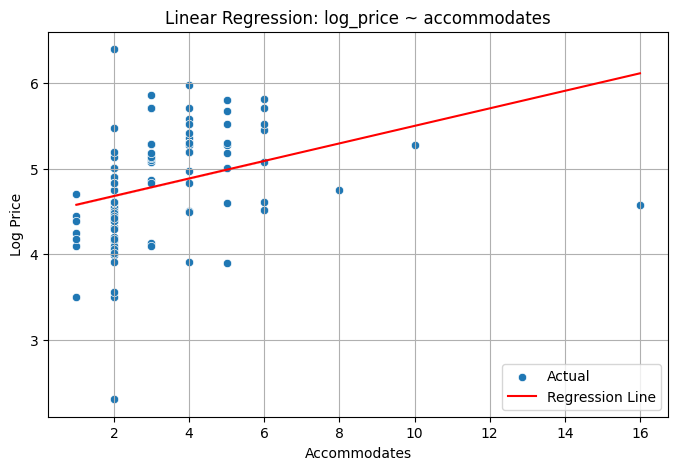

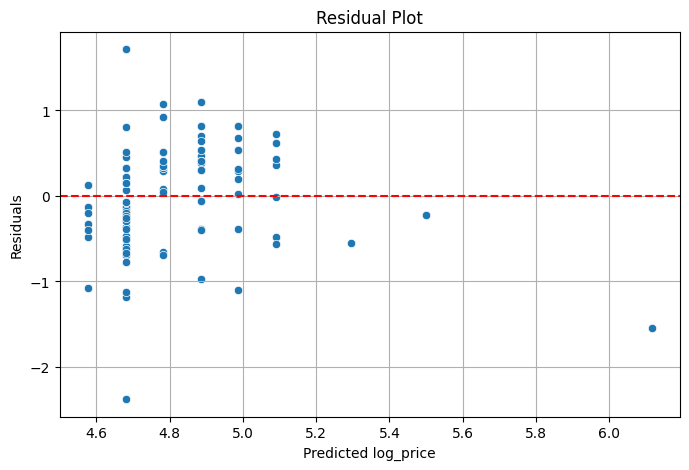

In [85]:
X = sampled_data[['accommodates']] # bedrooms  
y = sampled_data['log_price']

# Fit the model
linreg = LinearRegression()
linreg.fit(X, y)

# Predictions
y_pred = linreg.predict(X)

# Regression Equation
slope = linreg.coef_[0]
intercept = linreg.intercept_
print(f"Regression Equation: log_price = {intercept:.4f} + {slope:.4f} × accommodates")

# R² and MSE
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
print(f"R² Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

# Plot Regression Line
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X['accommodates'], y=y, label="Actual")
sns.lineplot(x=X['accommodates'], y=y_pred, color='red', label="Regression Line")
plt.title("Linear Regression: log_price ~ accommodates")
plt.xlabel("Accommodates")
plt.ylabel("Log Price")
plt.legend()
plt.grid(True)
plt.show()

# Plot Residuals
residuals = y - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted log_price")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()


Simple Linear Regression Evaluation: log_price ~ accommodates

We fitted a simple linear regression model to predict `log_price` using `accommodates` as the sole predictor.

Regression Equation:
\[
\text{log\_price} = 4.4749 + 0.1025 \times \text{accommodates}
\]

Model Performance:
- R² Score: 0.1074  
- Mean Squared Error (MSE): 0.3674

The R² value indicates that only about 10.7% of the variation in `log_price` is explained by `accommodates`, which is relatively low. This suggests that while `accommodates` has some effect on price, it is not a strong standalone predictor.

Residual Analysis:
The residual plot shows a non-random spread of residuals, with possible funneling and clustering. This violates the assumption of homoscedasticity (equal variance of residuals) and may suggest that a linear model is not fully appropriate or is missing key variables.

Conclusion:
The model captures a weak but statistically significant relationship between the number of people a listing accommodates and its log-transformed price. However, due to the low R² value and non-random residuals, this simple model is not sufficient for accurate prediction of `log_price`. A multiple regression model with additional features is recommended for better performance — addressed in Requirement 5.


----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

5. Use your samples to find a multi-regression equation. (40 points). Finally,
print your adjusted R2 (10 points). There should be three different models to
predict the target variable. Which one of these models is the best to predict
your target variable, and why (10 points)?

In [86]:
def run_model(features, target):
    model = LinearRegression()
    model.fit(features, target)
    y_pred = model.predict(features)
    
    # Evaluation
    r2 = model.score(features, target)
    n = features.shape[0]
    p = features.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    mse = mean_squared_error(target, y_pred)
    
    return model, r2, adj_r2, mse

# Target
y = sampled_data['log_price']

# Model 1: One predictor
X1 = sampled_data[['accommodates']]
model1, r2_1, adj_r2_1, mse_1 = run_model(X1, y)

# Model 2: Two predictors
X2 = sampled_data[['accommodates', 'bedrooms']]
model2, r2_2, adj_r2_2, mse_2 = run_model(X2, y)

# Model 3: Three predictors
X3 = sampled_data[['accommodates', 'bedrooms', 'cleaning_fee']]
model3, r2_3, adj_r2_3, mse_3 = run_model(X3, y)

# Display results
print("Model 1: log_price ~ accommodates")
print(f"  R²: {r2_1:.4f}, Adjusted R²: {adj_r2_1:.4f}, MSE: {mse_1:.4f}")

print("\nModel 2: log_price ~ accommodates + bedrooms")
print(f"  R²: {r2_2:.4f}, Adjusted R²: {adj_r2_2:.4f}, MSE: {mse_2:.4f}")

print("\nModel 3: log_price ~ accommodates + bedrooms + cleaning_fee")
print(f"  R²: {r2_3:.4f}, Adjusted R²: {adj_r2_3:.4f}, MSE: {mse_3:.4f}")


Model 1: log_price ~ accommodates
  R²: 0.1074, Adjusted R²: 0.0983, MSE: 0.3674

Model 2: log_price ~ accommodates + bedrooms
  R²: 0.1199, Adjusted R²: 0.1018, MSE: 0.3622

Model 3: log_price ~ accommodates + bedrooms + cleaning_fee
  R²: 0.1251, Adjusted R²: 0.0977, MSE: 0.3601


Multiple Linear Regression Analysis

We developed and compared three multiple linear regression models to predict the target variable `log_price` using different combinations of predictors:

| Model | Predictors                               | R²     | Adjusted R² | MSE     |
|-------|------------------------------------------|--------|-------------|---------|
| 1     | accommodates                             | 0.1074 | 0.0983      | 0.3674  |
| 2     | accommodates, bedrooms                   | 0.1199 | 0.1018      | 0.3622  |
| 3     | accommodates, bedrooms, cleaning_fee     | 0.1251 | 0.0977      | 0.3601  |

Interpretation:

- Model 1 (1 predictor) gives a baseline with modest explanatory power.
- Model 2 adds `bedrooms` and slightly improves both R² and adjusted R².
- Model 3 includes `cleaning_fee` and shows the highest R², but its adjusted R² decreases, suggesting the added variable does not improve the model significantly when accounting for complexity.

Final Conclusion:

While Model 3 has the highest R² (0.1251), it also has the lowest adjusted R² (0.0977). Since adjusted R² accounts for the number of predictors and penalizes unnecessary complexity, we conclude that Model 2 is the best model overall.

Model 2 strikes the best balance between simplicity and explanatory power, with a solid adjusted R² and lower MSE than Model 1.

This shows that adding more predictors doesn't always improve model performance — it's important to evaluate both raw fit (R²) and adjusted fit.
